# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import pandas as pd
import numpy as np

from pathlib import Path

import dask.array as da
from spectralcrop import PathManager

# --- Geoespacial ---
import rioxarray
import geopandas as gpd
import rasterio
from rasterio import features
from affine import Affine

# --- Visualización ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import joblib


# ===============================
# Machine Learning clásico
# ===============================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb

import mlflow
import dagshub
import optuna
from lazypredict.Supervised import LazyClassifier
import sklearn
import lightgbm as lgbm
from lightgbm import LGBMClassifier

In [3]:
interim_data = PathManager().get_abs_path_folder("interim")
zarr_path = interim_data + "masked_reflectance.zarr"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

In [4]:
dagshub.init(repo_owner='johnma96', repo_name='thesis', mlflow=True)

Accessing as johnma96

Initialized MLflow to track repo "johnma96/thesis"

Repository johnma96/thesis initialized!

# Cargar información

## Cubo de datos

In [5]:
ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]
nodata_mask = ds["mask_nodata"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")



<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


In [6]:
# Contar NaNs por píxel en reflectancia
nan_counts = refl_byx.isnull().sum(dim=["y", "x"])  # suma sobre y y x

In [7]:
print(nan_counts.values.max(), nan_counts.values.min())

6432671 6411637


In [8]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = refl_byx.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")


Píxeles con ≥1 NaN: 6484992 (51.54%)


In [9]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [10]:
# Pixeles válidos - vegetación
(veg_mask == 1).values.sum().sum() 

np.int64(6127993)

In [11]:
# Pixeles inválidos - vegetación
(veg_mask == 1).shape[0]*(veg_mask == 1).values.shape[1] - (veg_mask == 1).values.sum().sum()

np.int64(6455087)

In [12]:
nodata_mask

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...

In [13]:
# Pixeles válidos - no datos
(nodata_mask == 0).values.sum().sum()

np.int64(6098088)

In [14]:
# Pixeles inválidos - no datos
(nodata_mask == 0).shape[0]*(nodata_mask == 0).values.shape[1] - (nodata_mask == 0).values.sum().sum()

np.int64(6484992)

In [15]:
# -----------------------------
# Máscaras validadas para datos
# -----------------------------

valid_mask = (veg_mask & (nodata_mask == 0))
valid_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [16]:
# Pixeles válidos
valid_mask.values.sum().sum()

np.int64(6055113)

In [17]:
# Pixeles inválidos
valid_mask.values.shape[0]*valid_mask.values.shape[1] - valid_mask.values.sum().sum()

np.int64(6527967)

Pixeles válidos: 6,055,113 (48.12%)


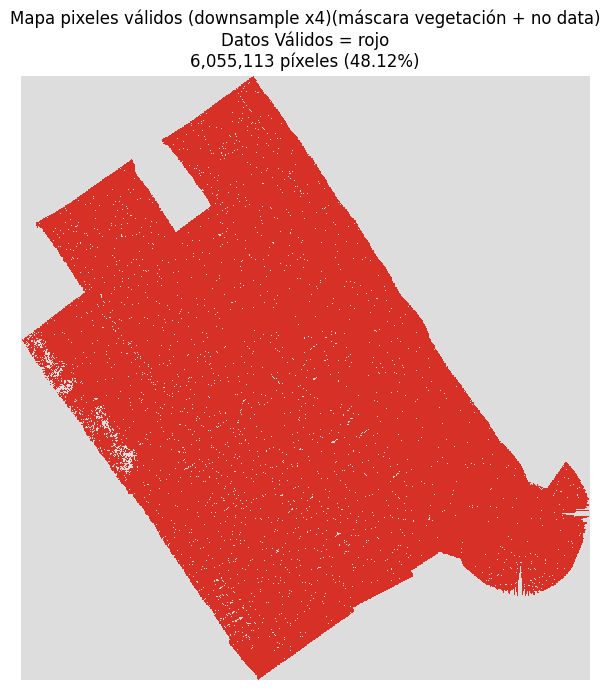

In [18]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---


# 2) Estadísticos rápidos
total_px = valid_mask.sizes["y"] * valid_mask.sizes["x"]
nodata_px = int(valid_mask.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles válidos: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = valid_mask.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa pixeles válidos (downsample x{stride})(máscara vegetación + no data)\nDatos Válidos = rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
# plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

## Etiquetas

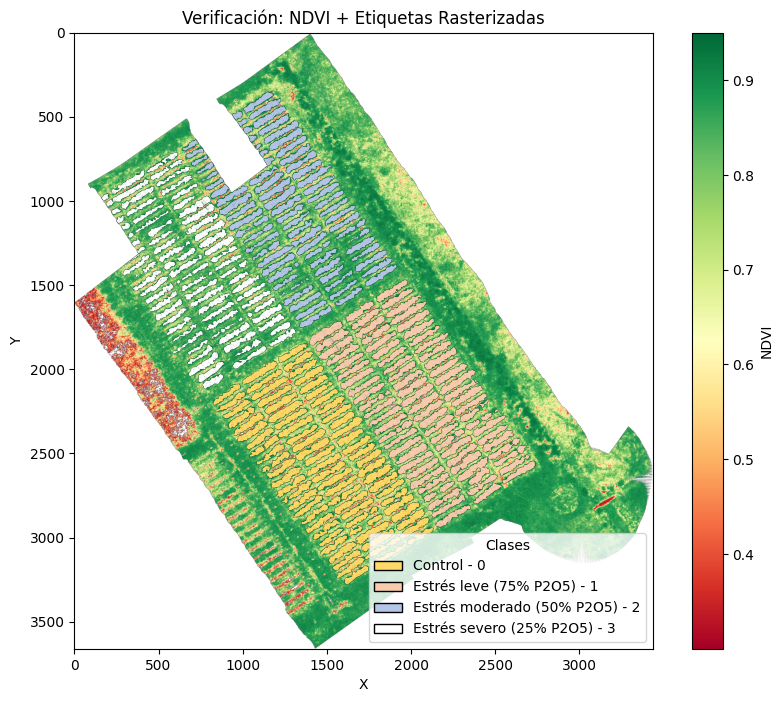

In [19]:
# --- Rutas ---
labels_tiff_path = Path(PathManager().get_abs_path_file("labels_multiclass.tif"))

ndvi = ds["NDVI"].compute()  # Cargar NDVI en memoria para graficar

# --- Obtener transform y CRS ---
crs = ndvi.rio.crs
transform = ndvi.rio.transform()
height, width = ndvi.shape

# Calcular extent para imshow
x_min = transform.c
x_max = transform.c + width * transform.a
y_max = transform.f
y_min = transform.f + height * transform.e  # e es negativo
extent = (x_min, x_max, y_min, y_max)

# --- Abrir GeoTIFF de etiquetas ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)

# --- Graficar overlay ---
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")


# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estrés leve (75% P2O5) - 1",
    2: "Estrés moderado (50% P2O5) - 2",
    3: "Estrés severo (25% P2O5) - 3",
}
colors = ["#FFD966", "#F8CBAD", "#B4C6E7", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

masked_labels = np.ma.masked_where(labels == 255, labels)
ax.imshow(masked_labels, cmap=cmap_labels, alpha=1, extent=extent, origin="upper")

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación: NDVI + Etiquetas Rasterizadas")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()

In [20]:
# --- Abrir etiquetas como array ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)  # numpy array (y, x)

# Convertir a binario: 0 = control, resto (1,2,3) = enfermo
labels_bin = np.where(labels == 0, 0, 
                      np.where(
                          np.isin(labels, [1, 2, 3]), 1, np.nan
                        )
                    )

# Aplicar máscara veg-valid
# labels_bin = np.where(valid_mask, labels_bin, np.nan)

In [21]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [22]:
np.isnan(labels_bin).sum().sum()

np.int64(10834441)

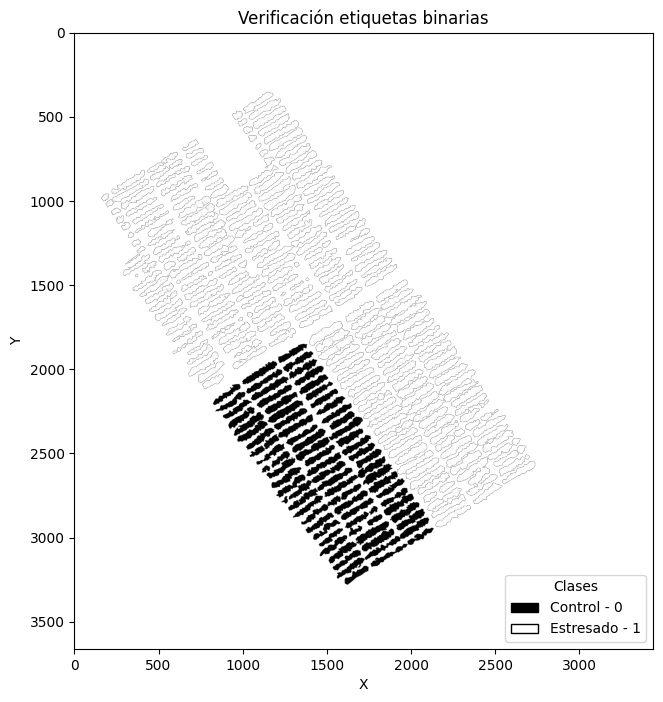

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

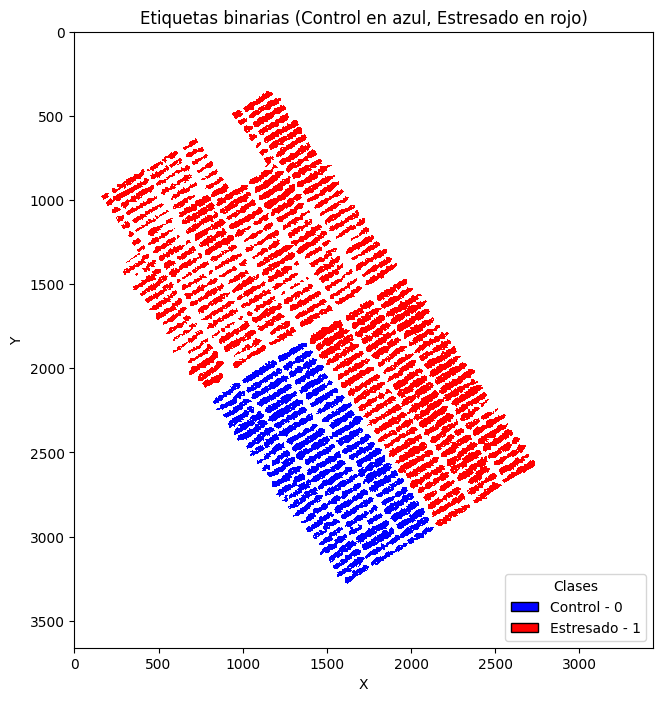

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()


In [25]:
np.isnan(labels_bin).sum()

np.int64(10834441)

In [26]:
labels_bin.shape[0] * labels_bin.shape[1] - np.isnan(labels_bin).sum()

np.int64(1748639)

# 1. Preparación de datos

## 1.1 Preparar matriz de características X

In [27]:
# -----------------------------
# 5. Extraer índices espectrales y bandas clave
# -----------------------------
# Índices ya calculados en Zarr: NDVI, NDRE, CIgreen, PRI, PSRI
indices = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]]

# Selección de bandas clave por correlación - ver notebook 201-jmmz-select-bands-by-correlation.ipynb
path_selected_bands = PathManager().get_abs_path_file("bands_selected_by_segment.csv")
selected_bands_df = pd.read_csv(path_selected_bands)
selected_bands = selected_bands_df['band_index'].tolist()

reflectance_selected = ds["reflectance"].isel(band=selected_bands)
reflectance_selected

<xarray.DataArray 'reflectance' (band: 58, y: 3660, x: 3438)> Size: 3GB
dask.array<getitem, shape=(58, 3660, 3438), dtype=float32, chunksize=(58, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 232B 1 13 31 41 48 55 67 ... 348 350 352 355 362 374
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']

In [28]:
indices_da = indices.to_array(dim="band")
indices_da

<xarray.DataArray (band: 5, y: 3660, x: 3438)> Size: 252MB
dask.array<stack, shape=(5, 3660, 3438), dtype=float32, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 40B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI'
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [29]:
nan_counts = indices_da.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)

[6527967 6528031 7596119 7071551 6575062]


In [30]:
# "NDVI", "NDRE", "CIgreen", "PRI", "PSRI"
(~indices_da.isnull()).sum(dim=["y", "x"]).values

# -> CIgreen tiene más NaN que el resto

array([6055113, 6055049, 4986961, 5511529, 6008018])

In [31]:
# -----------------------------
# 6. Construir DataFrame para ML
# -----------------------------
# Aplanar datos válidos
features_stack = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack = features_stack.transpose("y", "x", "band")
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [32]:
nan_counts = features_stack.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)


[6527967 6528031 7596119 7071551 6575062 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637 6411637
 6411637 6411637 6411637 6411795 6411976 6411921 6412079 6412215 6411748
 6411746 6411768 6411798 6411680 6411663 6411652 6411664 6411678 6411680
 6411708 6411701 6411753 6411742 6411805 6412085 6411960 6412297 6411998]


In [33]:

print("Size features:", features_stack.sizes)
print("Size labels:", labels_bin.shape)


Size features: Frozen({'y': 3660, 'x': 3438, 'band': 63})
Size labels: (3660, 3438)


In [34]:
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<transpose, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [35]:
labels_bin.shape[0]*labels_bin.shape[1]

12583080

In [36]:
# Máscara para extraer solo píxeles válidos
valid_pixels = valid_mask #& ~np.isnan(labels_bin)
valid_pixels.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [37]:
# Extraer valores
X = features_stack.where(valid_pixels)#.values.reshape(-1, features_stack.shape[-1])
X

<xarray.DataArray (y: 3660, x: 3438, band: 63)> Size: 3GB
dask.array<where, shape=(3660, 3438, 63), dtype=float32, chunksize=(512, 512, 58), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 504B 'NDVI' 'NDRE' 'CIgreen' 'PRI' ... 355 362 374
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [38]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = ds['reflectance'].isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6484992 (51.54%)


In [39]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = reflectance_selected.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6416232 (50.99%)


In [40]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = indices_da.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


In [41]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = features_stack.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100



print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")
print(f"Píxeles válidos: {features_stack.shape[0]*features_stack.shape[1] - count_nan_pixels}")

Píxeles con ≥1 NaN: 7596119 (60.37%)
Píxeles válidos: 4986961


In [42]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = X.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


Voy a enmascarar los labels para que coincidan con X

In [43]:
X.isnull().any(dim="band").values

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(3660, 3438))

In [44]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [45]:

# Enmascarar: donde mask_nan_pixels == True -> NaN
labels_bin_masked = np.where(X.isnull().any(dim="band").values, np.nan, labels_bin)
labels_bin_masked

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

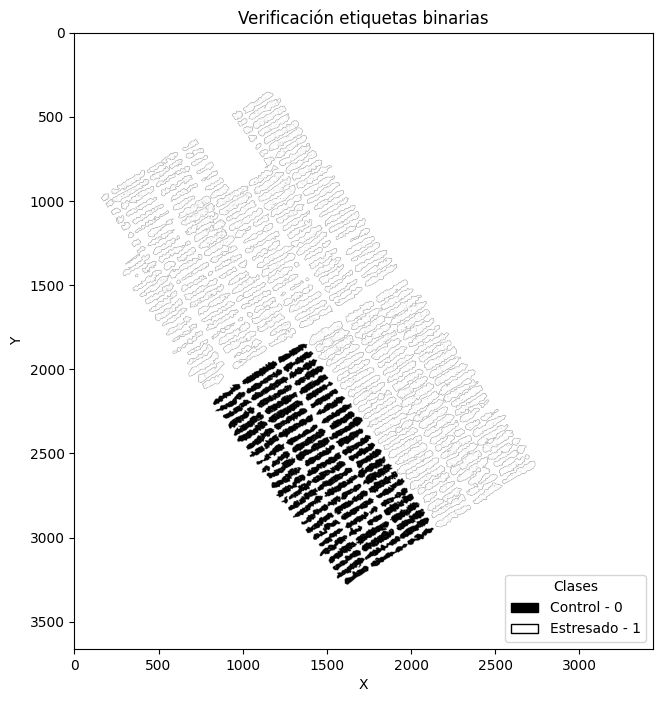

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin_masked, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()


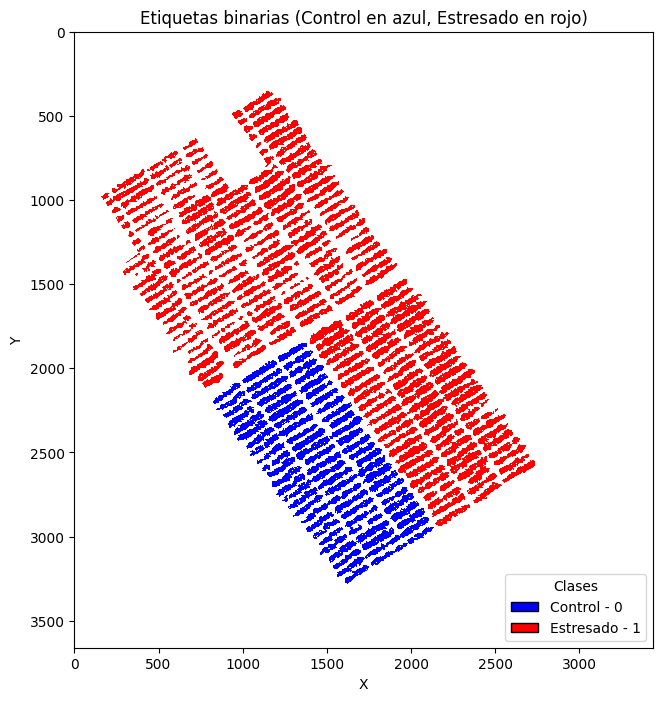

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin_masked, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [48]:
np.isnan(labels_bin_masked).sum()

np.int64(10868816)

In [49]:
labels_bin_masked.shape[0] * labels_bin_masked.shape[1] - np.isnan(labels_bin_masked).sum()

np.int64(1714264)

Hay 1714264 labels que tienen todos los features válidos y  además tienen etiqueta válida (0 o 1).

In [50]:
X2 = X.values.reshape(-1, features_stack.shape[-1])
X2

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(12583080, 63), dtype=float32)

In [51]:
labels_bin.reshape(-1)

array([nan, nan, nan, ..., nan, nan, nan], shape=(12583080,))

In [52]:
## Cargar el split espacial del notebook 302-jmmz-spatial-split.ipynb
OUT_SPLIT_TIFF = PathManager().get_abs_path_folder('processed') + "/splits/by_plot_split_id_binary.tif"

with rasterio.open(OUT_SPLIT_TIFF) as src:
    split_id = src.read(1)


split_id

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3660, 3438), dtype=uint8)

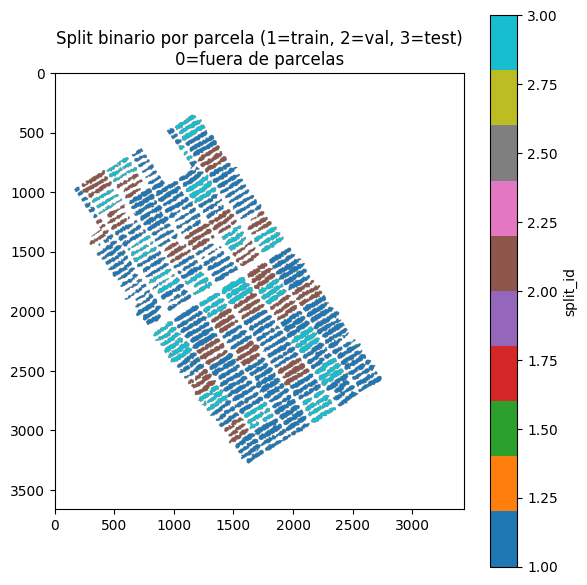

Conteo de píxeles por split: {np.uint8(1): np.int64(1038541), np.uint8(2): np.int64(353211), np.uint8(3): np.int64(372966)}


In [53]:
plt.figure(figsize=(6,6))
plt.imshow(np.where(split_id==0, np.nan, split_id), cmap="tab10", vmin=1, vmax=3)
plt.title("Split binario por parcela (1=train, 2=val, 3=test)\n0=fuera de parcelas")
plt.colorbar(label="split_id")
plt.tight_layout()
plt.show()

# Conteo de píxeles por split dentro de parcelas
vals, counts = np.unique(split_id[split_id>0], return_counts=True)
print("Conteo de píxeles por split:", dict(zip(vals, counts)))

In [54]:
np.unique(np.where(split_id==0, np.nan, split_id).reshape(-1, 1))

array([ 1.,  2.,  3., nan])

In [55]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [56]:
data = np.concatenate([X2, 
                       labels_bin.reshape(-1, 1),
                     #   split_id.reshape(-1, 1),
                       np.where(split_id==0, np.nan, split_id).reshape(-1, 1),
                       ], axis=1)
data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12583080, 65))

In [57]:
X2[0]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
      dtype=float32)

In [58]:
pd.DataFrame(data).head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
pd.DataFrame(X2).shape[0] - pd.DataFrame(X2).isna().sum()

# La columna que corresponde a CIgreen tiene más NaN que el resto

0     6055113
1     6055049
2     4986961
3     5511529
4     6008018
       ...   
58    6055113
59    6055113
60    6055113
61    6055113
62    6055113
Length: 63, dtype: int64

In [60]:
pd.DataFrame(X2).dropna(axis=0, how='any')

# CIgreen tiene más NaN que el resto, por tanto controla el shape final de X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
18591,0.88,0.39,6.27,-0.03,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
18592,0.88,0.42,7.57,-0.04,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
22027,0.89,0.45,8.16,-0.04,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
22028,0.88,0.41,6.77,-0.04,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
22029,0.88,0.41,6.77,-0.04,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12567322,0.88,0.31,4.50,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
12567323,0.88,0.31,4.52,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
12567324,0.88,0.34,4.97,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
12570760,0.88,0.31,4.75,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [61]:
data_ = pd.DataFrame(data).dropna(axis=0, how='any')
data_.rename(columns={data_.columns[-2]: 'label'}, inplace=True)
data_.rename(columns={data_.columns[-1]: 'split'}, inplace=True)
data_ 

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,label,split
1204447,0.87,0.30,4.59,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
1204448,0.88,0.30,4.79,-0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
1207884,0.85,0.33,5.06,-0.03,0.01,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
1207885,0.88,0.30,4.50,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
1207886,0.88,0.30,4.52,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.89,0.37,7.14,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
11264514,0.88,0.40,8.37,-0.03,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
11267949,0.86,0.34,5.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
11267950,0.84,0.33,5.39,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [62]:
resumen_df = data_.groupby(["label", "split"]).size().unstack(fill_value=0).rename(
    columns={1: 'train', 2: 'val', 3: 'test'}
)

resumen_df

split,train,val,test
label,,,
0.00,304220,93238,92596
1.00,704959,250037,269214


In [63]:
resumen_df.div(resumen_df.sum(axis=0), axis=1) * 100

split,train,val,test
label,,,
0.00,30.15,27.16,25.59
1.00,69.85,72.84,74.41


## 1.2 Separar X y y validados

In [64]:
X = data_.drop(columns=["label", "split"])
y = data_.loc[:, "label"]
split = data_.loc[:, "split"]

In [65]:
X

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
1204447,0.87,0.30,4.59,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1204448,0.88,0.30,4.79,-0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1207884,0.85,0.33,5.06,-0.03,0.01,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1207885,0.88,0.30,4.50,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1207886,0.88,0.30,4.52,-0.01,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11264513,0.89,0.37,7.14,-0.02,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11264514,0.88,0.40,8.37,-0.03,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11267949,0.86,0.34,5.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11267950,0.84,0.33,5.39,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [66]:
y

1204447    1.00
1204448    1.00
1207884    1.00
1207885    1.00
1207886    1.00
           ... 
11264513   0.00
11264514   0.00
11267949   0.00
11267950   0.00
11267951   0.00
Name: label, Length: 1714264, dtype: float64

In [67]:
split

1204447    3.00
1204448    3.00
1207884    3.00
1207885    3.00
1207886    3.00
           ... 
11264513   1.00
11264514   1.00
11267949   1.00
11267950   1.00
11267951   1.00
Name: split, Length: 1714264, dtype: float64

In [68]:
print(f"Shape X: {X.shape}, Shape y: {y.shape}, shape split: {split.shape}, Clases: {np.unique(y)}, Split IDs: {np.unique(split)}")    

Shape X: (1714264, 63), Shape y: (1714264,), shape split: (1714264,), Clases: [0. 1.], Split IDs: [1. 2. 3.]


In [69]:
pd.Series(y).value_counts()

label
1.00    1224210
0.00     490054
Name: count, dtype: int64

## 1.3 Split de datos en train/test (Aplicando split espacial)

In [70]:
# División train, test, val usando los IDs espaciales cargados

X_train, X_val, X_test, y_train, y_val, y_test = (
    X[split == 1], X[split == 2], X[split == 3],
    y[split == 1], y[split == 2], y[split == 3],
)

In [71]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((1009179, 63), (1009179,), (361810, 63), (361810,), (343275, 63), (343275,))

In [72]:
resumen_df

split,train,val,test
label,,,
0.00,304220,93238,92596
1.00,704959,250037,269214


In [73]:
resumen_df.sum(axis=0)

split
train    1009179
val       343275
test      361810
dtype: int64

## 1.4 Scaler

### Create

In [74]:
# # -----------------------------
# # 3. Escalado robusto
# # -----------------------------
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# # 2. Scaler
# base_joblib_path = "../models/checkpoints/"
# joblib.dump(scaler, base_joblib_path + "robust_scaler.pkl")

### Load

In [75]:
base_joblib_path = "../models/checkpoints/"
scaler = joblib.load(filename=base_joblib_path + "robust_scaler.pkl")

In [76]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [77]:
X_train_scaled

array([[-5.2871528 , -0.64362406, -0.61960271, ..., -1.39999999,
        -0.83018882, -1.04395633],
       [-5.15468601, -0.58615462, -0.51652919, ..., -1.17777779,
        -0.71698126, -1.07692327],
       [-4.86535309, -0.74903358, -0.68467803, ..., -0.57777784,
        -0.54716986, -0.64835184],
       ...,
       [-1.57229569, -0.5235385 , -0.53152692, ...,  0.35555557,
         0.05660383, -0.95604417],
       [-2.28746317, -0.68332758, -0.69579574, ...,  1.0888887 ,
        -1.32075495, -1.34065964],
       [-1.68315149, -0.49355267, -0.44228863, ...,  0.15555542,
        -1.11320778, -1.4945058 ]], shape=(1009179, 63))

In [78]:
X_test_scaled

array([[-1.31786473, -1.13053074, -1.00299263, ...,  0.08888896,
        -0.09433951, -0.40659364],
       [-0.72293183, -1.1663174 , -0.92334689, ...,  0.44444453,
         0.69811374,  0.57142832],
       [-1.90795932, -0.75582272, -0.82368839, ...,  0.84444433,
        -0.54716986,  0.07692277],
       ...,
       [-1.50236409,  0.10928074,  0.77365541, ..., -0.97777776,
        -0.15094334,  0.47252751],
       [-0.3338865 ,  0.10506473,  0.71728979, ..., -1.42222216,
        -0.28301874, -0.04395633],
       [-0.5329734 ,  0.2866558 ,  0.74021197, ..., -0.79999997,
        -0.3018869 , -0.6813189 ]], shape=(361810, 63))

# 2. LazyPredict

Se utiliza para protipado rápido y evaluar algunos algoritmos destacables para el dataset

In [ ]:
classifiers = [
                ('AdaBoostClassifier', sklearn.ensemble._weight_boosting.AdaBoostClassifier),
                ('CategoricalNB', sklearn.naive_bayes.CategoricalNB),
                ('DecisionTreeClassifier', sklearn.tree._classes.DecisionTreeClassifier),
                ('DummyClassifier', sklearn.dummy.DummyClassifier),
                #  ('ExtraTreeClassifier', sklearn.tree._classes.ExtraTreeClassifier),
                #  ('ExtraTreesClassifier', sklearn.ensemble._forest.ExtraTreesClassifier),
                ('GaussianNB', sklearn.naive_bayes.GaussianNB),
                ('KNeighborsClassifier', sklearn.neighbors._classification.KNeighborsClassifier),
                ('LogisticRegression', sklearn.linear_model._logistic.LogisticRegression),
                ('Perceptron', sklearn.linear_model._perceptron.Perceptron),
                ('RandomForestClassifier', sklearn.ensemble._forest.RandomForestClassifier),
                ('RidgeClassifier', sklearn.linear_model._ridge.RidgeClassifier),
                ('SGDClassifier', sklearn.linear_model._stochastic_gradient.SGDClassifier),
                ('XGBClassifier', xgb.sklearn.XGBClassifier),
                ('LGBMClassifier', lgbm.sklearn.LGBMClassifier)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 13/13 [11:42<00:00, 54.03s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
GaussianNB,0.53,0.53,0.53,0.56,3.81
DecisionTreeClassifier,0.60,0.51,0.51,0.61,99.25
KNeighborsClassifier,0.66,0.51,0.51,0.64,356.06
AdaBoostClassifier,0.74,0.50,0.50,0.63,220.29
DummyClassifier,0.74,0.50,0.50,0.63,2.67
LogisticRegression,0.71,0.50,0.50,0.64,14.12


In [ ]:
classifiers = [
                ('Perceptron', sklearn.linear_model._perceptron.Perceptron)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 7/7 [04:51<00:00, 41.66s/it] 


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
Perceptron,0.62,0.52,0.52,0.62,6.91


In [ ]:
classifiers = [
                ('XGBClassifier', xgb.sklearn.XGBClassifier),
                ('LGBMClassifier', lightgbm.sklearn.LGBMClassifier)
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


 50%|█████     | 1/2 [00:10<00:10, 10.44s/it]

[LightGBM] [Info] Number of positive: 704959, number of negative: 304220
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15301
[LightGBM] [Info] Number of data points in the train set: 1009179, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.698547 -> initscore=0.840389
[LightGBM] [Info] Start training from score 0.840389


100%|██████████| 2/2 [00:21<00:00, 10.75s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.73,0.51,0.51,0.65,10.44
LGBMClassifier,0.74,0.50,0.50,0.64,11.06


In [ ]:
classifiers = [
                ('RandomForestClassifier', sklearn.ensemble._forest.RandomForestClassifier),
                ('RidgeClassifier', sklearn.linear_model._ridge.RidgeClassifier),
                ('SGDClassifier', sklearn.linear_model._stochastic_gradient.SGDClassifier),
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 4/4 [12:48<00:00, 192.15s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.74,0.50,0.50,0.64,754.32
RidgeClassifier,0.73,0.50,0.50,0.64,3.93
SGDClassifier,0.74,0.50,0.50,0.63,7.99


In [81]:
classifiers = [
                ('CategoricalNB', sklearn.naive_bayes.CategoricalNB),
                ]


clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric=None, classifiers=classifiers)

models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
models

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 1/1 [00:02<00:00,  2.11s/it]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,


# 3. Modelado con XGBoost

## 3.1 Modelo sin optimización de hiperparámetros

In [84]:
mlflow.set_experiment("xgboost")

<Experiment: artifact_location='mlflow-artifacts:/525540c52c1b4855953681bde9a954ae', creation_time=1767804157407, experiment_id='3', last_update_time=1767804157407, lifecycle_stage='active', name='xgboost', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [78]:
# 1) Manejo del desbalance: calcular scale_pos_weight SOLO con TRAIN (positiva=1)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220


### Prueba rápida


--- Reporte de clasificación ---
              precision    recall  f1-score   support

         0.0      0.311     0.594     0.408     92596
         1.0      0.797     0.546     0.648    269214

    accuracy                          0.559    361810
   macro avg      0.554     0.570     0.528    361810
weighted avg      0.672     0.559     0.587    361810

ROC-AUC: 0.599

Matriz de confusión:
[[ 55035  37561]
 [122133 147081]]


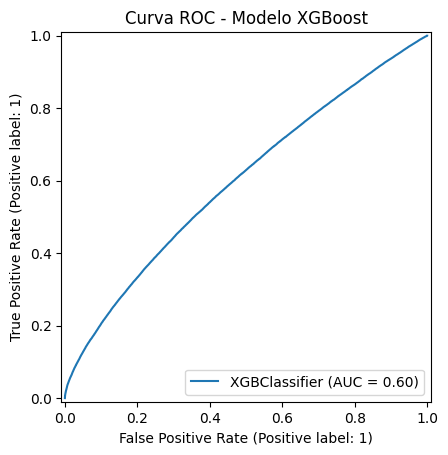

In [83]:
# -----------------------------
# 4. Modelo XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 5. Predicciones y métricas
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de clasificación ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 6. Curva ROC
# -----------------------------
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Curva ROC - Modelo XGBoost")
plt.show()


--- Reporte de clasificación ---
              precision    recall  f1-score   support

         0.0      0.311     0.594     0.408     92596
         1.0      0.797     0.546     0.648    269214

    accuracy                          0.559    361810
   macro avg      0.554     0.570     0.528    361810
weighted avg      0.672     0.559     0.587    361810

ROC-AUC: 0.599

Matriz de confusión:
[[ 55035  37561]
 [122133 147081]]


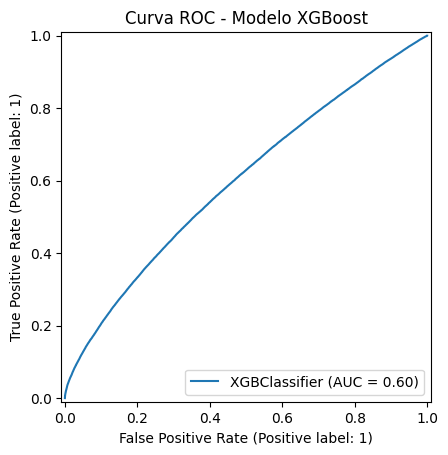

In [84]:
# -----------------------------
# 4. Modelo XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='aucpr'

)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 5. Predicciones y métricas
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de clasificación ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 6. Curva ROC
# -----------------------------
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Curva ROC - Modelo XGBoost")
plt.show()

### Early stopping y mejor threshold

xgboost version: 3.1.2
scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220
[0]	train-aucpr:0.74986	val-aucpr:0.76372
[50]	train-aucpr:0.78899	val-aucpr:0.78974
[100]	train-aucpr:0.79943	val-aucpr:0.79373
[150]	train-aucpr:0.80789	val-aucpr:0.79662
[200]	train-aucpr:0.81417	val-aucpr:0.79906
[250]	train-aucpr:0.81923	val-aucpr:0.80056
[300]	train-aucpr:0.82342	val-aucpr:0.80200
[350]	train-aucpr:0.82729	val-aucpr:0.80319
[400]	train-aucpr:0.83059	val-aucpr:0.80447
[450]	train-aucpr:0.83384	val-aucpr:0.80549
[500]	train-aucpr:0.83667	val-aucpr:0.80639
[550]	train-aucpr:0.83908	val-aucpr:0.80726
[600]	train-aucpr:0.84142	val-aucpr:0.80800
[650]	train-aucpr:0.84337	val-aucpr:0.80865
[700]	train-aucpr:0.84551	val-aucpr:0.80956
[750]	train-aucpr:0.84744	val-aucpr:0.81016
[800]	train-aucpr:0.84935	val-aucpr:0.81086
[850]	train-aucpr:0.85101	val-aucpr:0.81122
[900]	train-aucpr:0.85260	val-aucpr:0.81159
[950]	train-aucpr:0.85420	val-aucpr:0.81203
[1000]	train-aucpr:0.85562	val-aucpr:0.8

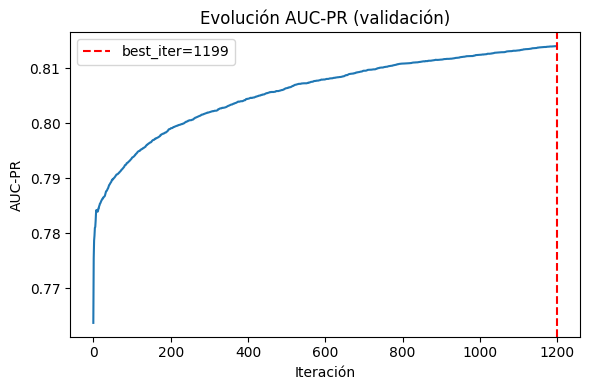

In [130]:
# 1) Manejo del desbalance: calcular scale_pos_weight SOLO con TRAIN (positiva=1)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"xgboost version: {xgb.__version__}")
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

# 2) Construir DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# 3) Parámetros (objetivo binario + AUC-PR + desbalance)
params = {
    "objective": "binary:logistic",
    "max_depth": 6,
    "eta": 0.03,                   # learning_rate (más bajo para early stopping fino)
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "aucpr",        # métrica de validación (mejor en desbalance)
    "scale_pos_weight": scale_pos_weight,
    "max_delta_step": 1,           # estabiliza actualización con desbalance
    "tree_method": "hist",
    "nthread": -1,
    "seed": 42
}

# 4) Entrenar con early stopping
evallist = [(dtrain, "train"), (dval, "val")]
evals_result = {}
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1200,          # máximo de árboles; early stopping escogerá menos si conviene
    evals=evallist,
    early_stopping_rounds=100,
    verbose_eval=50,
    evals_result=evals_result
)

val_aucpr = evals_result['val']['aucpr']
plt.figure(figsize=(6,4))
plt.plot(val_aucpr)
plt.axvline(bst.best_iteration, color='r', linestyle='--', 
            label=f'best_iter={bst.best_iteration}')
plt.title('Evolución AUC-PR (validación)')
plt.xlabel('Iteración')
plt.ylabel('AUC-PR')
plt.legend()
plt.tight_layout()
plt.show()

In [131]:

print(f"best_iteration: {bst.best_iteration} | best_aucpr(val): {bst.best_score:.4f}")

best_iteration: 1199 | best_aucpr(val): 0.8140


Umbral óptimo VAL: 0.450 | F1_macro=0.573

--- Reporte de clasificación (TEST) ---
              precision    recall  f1-score   support

         0.0      0.327     0.409     0.364     92596
         1.0      0.778     0.711     0.743    269214

    accuracy                          0.634    361810
   macro avg      0.553     0.560     0.553    361810
weighted avg      0.662     0.634     0.646    361810

ROC-AUC (test): 0.6018318284049798
PR-AUC  (test): 0.8161453633329118

Matriz de confusión (TEST):
[[ 37896  54700]
 [ 77846 191368]]


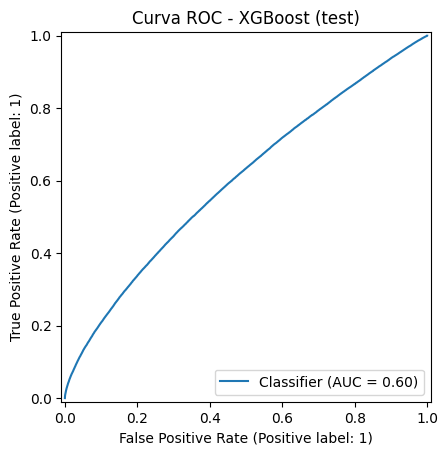

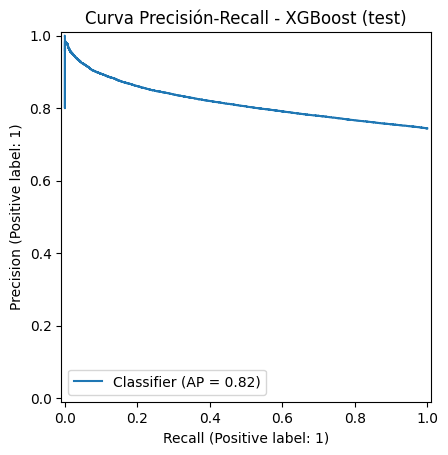

In [132]:
# 5) Probabilidades usando iteration_range
best_iter = getattr(bst, "best_iteration", None)
if best_iter is not None:
    y_prob_val  = bst.predict(dval,  iteration_range=(0, best_iter + 1))
    y_prob_test = bst.predict(dtest, iteration_range=(0, best_iter + 1))
else:
    y_prob_val  = bst.predict(dval)
    y_prob_test = bst.predict(dtest)

# 6) Umbral óptimo en VAL (F1 macro)
thr_grid = np.linspace(0.10, 0.90, 161)
best_thr, best_f1 = max(
    ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
    key=lambda x: x[1]
)
print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

# 7) Métricas en TEST
y_pred_test = (y_prob_test >= best_thr).astype(int)
print("\n--- Reporte de clasificación (TEST) ---")
print(classification_report(y_test, y_pred_test, digits=3))
print("ROC-AUC (test):", roc_auc_score(y_test, y_prob_test))
print("PR-AUC  (test):", average_precision_score(y_test, y_prob_test))
print("\nMatriz de confusión (TEST):")
print(confusion_matrix(y_test, y_pred_test))

# 8) Curvas ROC y PR (TEST)
RocCurveDisplay.from_predictions(y_test, y_prob_test)
plt.title("Curva ROC - XGBoost (test)"); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
plt.title("Curva Precisión-Recall - XGBoost (test)"); plt.show()

### MLflow agregado

In [ ]:
def train_xgboost_pipeline(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="xgboost_with_scaler",
        xgboost_params = None
    ):

    figs_path = PathManager().get_abs_path_folder('figures')
    models_path = PathManager().get_abs_path_folder('models')
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # -----------------------------
    # scale_pos_weight
    # -----------------------------
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / n_pos

    # -----------------------------
    # Pipeline = scaler + modelo
    # -----------------------------

    if xgboost_params is None:
        xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "scale_pos_weight": scale_pos_weight,
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 500,
            "n_jobs": -1,
            "early_stopping_rounds": 100,
            "random_state": 42,
            "verbosity": 3
        }
    else:
        xgboost_params.setdefault('scale_pos_weight', scale_pos_weight)

    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("xgb", XGBClassifier(
            **xgboost_params
        ))
    ])


    # ===================================================
    # MLflow
    # ===================================================
    with mlflow.start_run(run_name=run_name):
        
        mlflow.log_params(xgboost_params)
        mlflow.log_param("uses_pipeline_scaler", True)

        # -----------------------------
        # FIT (train + val early stopping)
        # -----------------------------

        # # Es importante hacer notar que en esta forma los conjuntos de validación no están siendo escalados
        # # internamente por el wrapper de sklearn, por lo cual se procesde a hacerlo manualmente
        # # Otra opción es unar la API nativa con xgb.train
        # model.fit(
        #         X_train,
        #         y_train,
        #         xgb__eval_set=[(X_val, y_val)],
        #         xgb__verbose=True
        #     )


        # AJUSTE MANUAL DE LOS DATASETS
        # Ajusta scaler primero
        model.named_steps["scaler"].fit(X_train)

        X_train_s = model.named_steps["scaler"].transform(X_train)
        X_val_s   = model.named_steps["scaler"].transform(X_val)

        model.named_steps["xgb"].fit(
            X_train_s, y_train,
            eval_set=[(X_val_s, y_val)],
            verbose=True
        )

        # ============================
        # Evolución AUC-PR
        # ============================

        results = model.named_steps["xgb"].evals_result()
        aucpr_curve = results["validation_0"]["aucpr"]

        plt.figure(figsize=(6,4))
        plt.plot(aucpr_curve)
        plt.axvline(model.named_steps["xgb"].best_iteration, color='r', linestyle='--', 
                    label=f'best_iter={model.named_steps["xgb"].best_iteration}')
        plt.title('Evolución AUC-PR (validación)')
        plt.xlabel('Iteración')
        plt.ylabel('AUC-PR')
        plt.legend()
        plt.tight_layout()
        
        artifact_name = f"evolution_pr_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)


        # -----------------------------
        # Probabilities
        # -----------------------------
        y_prob_val = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]

        # -----------------------------
        # Threshold tuning
        # -----------------------------
        thr_grid = np.linspace(0.01, 0.99, 199)

        best_thr, best_f1 = max(
                ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
                key=lambda x: x[1]
            )

        # 6) Umbral óptimo en VAL (F1 macro)
        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro")) for t in thr_grid),
            key=lambda x: x[1]
        )
        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        # -----------------------------
        # TEST
        # -----------------------------
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # ============================
        # Confusion Matrix
        # ============================
        cm = confusion_matrix(y_test, y_pred_test)

        print(cm)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_name = f"confusion_matrix_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # ============================
        # ROC & PR curves
        # ============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        artifact_name = f"roc_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        artifact_name = f"pr_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # # -----------------------------
        # # Save FULL pipeline (model + scaler)
        # # -----------------------------

        # Local
        model_path_local = models_path + f"{run_name}.pkl"
        joblib.dump(model, model_path_local)


        # Guardar modelo versionado en MLflow
        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr


[0]	validation_0-aucpr:0.76372
[1]	validation_0-aucpr:0.77546
[2]	validation_0-aucpr:0.77869
[3]	validation_0-aucpr:0.77958
[4]	validation_0-aucpr:0.78099
[5]	validation_0-aucpr:0.78116
[6]	validation_0-aucpr:0.78229
[7]	validation_0-aucpr:0.78376
[8]	validation_0-aucpr:0.78425
[9]	validation_0-aucpr:0.78404
[10]	validation_0-aucpr:0.78399
[11]	validation_0-aucpr:0.78394
[12]	validation_0-aucpr:0.78402
[13]	validation_0-aucpr:0.78452
[14]	validation_0-aucpr:0.78454
[15]	validation_0-aucpr:0.78493
[16]	validation_0-aucpr:0.78509
[17]	validation_0-aucpr:0.78539
[18]	validation_0-aucpr:0.78545
[19]	validation_0-aucpr:0.78564
[20]	validation_0-aucpr:0.78584
[21]	validation_0-aucpr:0.78597
[22]	validation_0-aucpr:0.78608
[23]	validation_0-aucpr:0.78623
[24]	validation_0-aucpr:0.78625
[25]	validation_0-aucpr:0.78646
[26]	validation_0-aucpr:0.78648
[27]	validation_0-aucpr:0.78660
[28]	validation_0-aucpr:0.78667
[29]	validation_0-aucpr:0.78672
[30]	validation_0-aucpr:0.78685
[31]	validation_0-

Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/07 16:51:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 22
Created version '22' of model 'bean_stress_classifier'.


🏃 View run xgboost_baseline at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/d0722931971748018a021281f851f06d
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


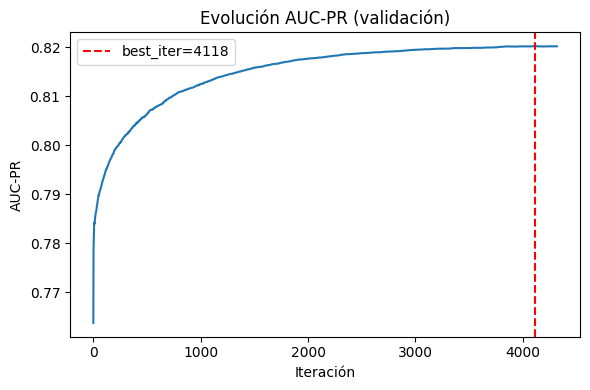

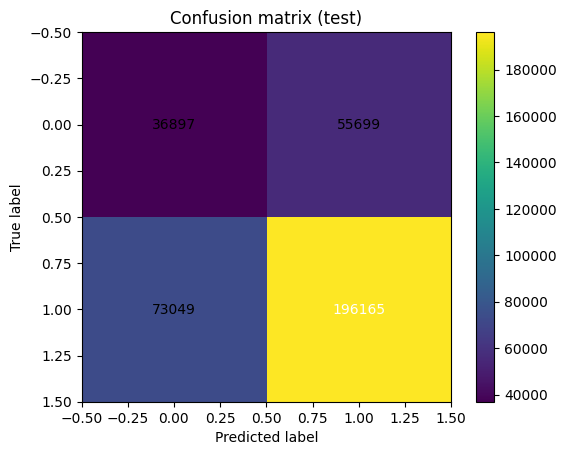

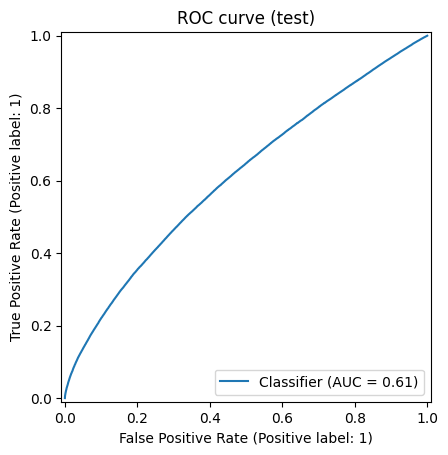

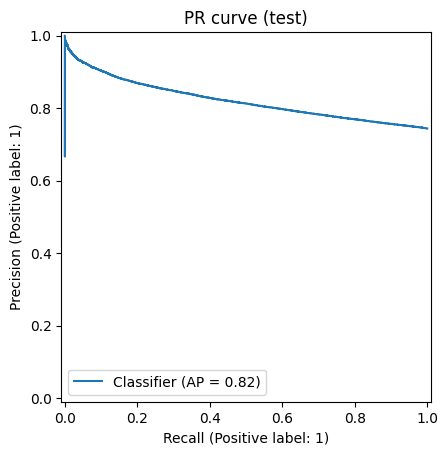

In [241]:
xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 5500,
            "n_jobs": -1,
            "early_stopping_rounds": 200,
            "random_state": 42,
            "verbosity": 3
        }

model, test_metrics, best_thr = train_xgboost_pipeline(
    X_train = X_train.values, y_train=y_train.values,
    X_val = X_val.values, y_val=y_val.values,
    X_test = X_test.values, y_test=y_test.values,
    run_name="xgboost_baseline",
    xgboost_params=xgboost_params
)

### Cross-validation agregado

In [108]:
def train_xgboost_pipeline_cv(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="xgboost_with_scaler_cv",
        xgboost_params=None,
        n_splits=5,
        seed=42
    ):

    figs_path = PathManager().get_abs_path_folder('figures')
    models_path = PathManager().get_abs_path_folder('models')
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # =============================
    # scale_pos_weight
    # =============================
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / n_pos

    if xgboost_params is None:
        xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "scale_pos_weight": scale_pos_weight,
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 500,
            "early_stopping_rounds": 100,
            "n_jobs": -1,
            "random_state": seed,
            "verbosity": 0
        }
    else:
        xgboost_params.setdefault("scale_pos_weight", scale_pos_weight)

    # =============================
    # MLflow
    # =============================
    with mlflow.start_run(run_name=run_name):

        mlflow.log_params(xgboost_params)
        mlflow.log_param("cv_folds", n_splits)
        mlflow.log_param("uses_pipeline_scaler", True)

        # =============================
        # 1️⃣ Cross-Validation (TRAIN only)
        # =============================
        print("Ejecutando Cross-Validation")

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )

        cv_scores = []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

            X_tr, X_va = X_train[tr_idx], X_train[val_idx]
            y_tr, y_va = y_train[tr_idx], y_train[val_idx]

            # NOTE: We manually fit scaler and XGBClassifier to allow eval_set with scaled data.
            # Both objects are references inside the Pipeline `model`.

            xgboost_params_cv = xgboost_params.copy()
            xgboost_params_cv['n_estimators'] = 1500
            xgboost_params_cv['early_stopping_rounds'] = 100
            xgboost_params_cv['verbosity'] = 0
            spw_fold = np.sum(y_tr == 0) / np.sum(y_tr == 1)
            xgboost_params_cv['scale_pos_weight'] = spw_fold

            model_fold = Pipeline(steps=[
                        ("scaler", RobustScaler()),
                        ("xgb", XGBClassifier(
                            **xgboost_params_cv
                        ))
                    ])
            
            scaler_fold = model_fold.named_steps["scaler"]

            X_tr_s = scaler_fold.fit_transform(X_tr)
            X_va_s = scaler_fold.transform(X_va)

            xgb_fold = model_fold.named_steps['xgb']

            xgb_fold.fit(
                X_tr_s, y_tr,
                eval_set=[(X_va_s, y_va)],
                verbose=False
            )

            y_prob_va = xgb_fold.predict_proba(X_va_s)[:, 1]
            pr_auc = average_precision_score(y_va, y_prob_va)

            cv_scores.append(pr_auc)

            mlflow.log_metric(f"cv_fold_{fold}_pr_auc", pr_auc)

        mean_cv_pr = np.mean(cv_scores)
        std_cv_pr  = np.std(cv_scores)

        mlflow.log_metric("cv_mean_pr_auc", mean_cv_pr)
        mlflow.log_metric("cv_std_pr_auc", std_cv_pr)

        best_fold = int(np.argmax(cv_scores))
        mlflow.log_param("best_cv_fold", best_fold + 1)

        # =============================
        # 2️⃣ Final training (TRAIN + VAL early stopping)
        # =============================
        # NOTE: We manually fit scaler and XGBClassifier to allow eval_set with scaled data.
        # Both objects are references inside the Pipeline `model`.
        model = Pipeline(steps=[
                ("scaler", RobustScaler()),
                ("xgb", XGBClassifier(
                    **xgboost_params
                ))
            ])
        
        # scaler = RobustScaler()
        scaler = model.named_steps["scaler"]
        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)

        # xgb_final = XGBClassifier(**xgboost_params)
        xgb_final = model.named_steps["xgb"]

        xgb_final.fit(
            X_train_s, y_train,
            eval_set=[(X_val_s, y_val)],
            verbose=True
        )

        # =============================
        # AUC-PR evolution
        # =============================
        results = xgb_final.evals_result()
        aucpr_curve = results["validation_0"]["aucpr"]

        plt.figure(figsize=(6,4))
        plt.plot(aucpr_curve)
        plt.axvline(
            xgb_final.best_iteration,
            color='r',
            linestyle="--",
            label=f"best_iter={xgb_final.best_iteration}"
        )
        plt.title('Evolución AUC-PR (validación)')
        plt.xlabel("Iteración")
        plt.ylabel("AUC-PR")
        plt.legend()

        artifact_path = figs_path + f"evolution_pr_{run_name}.png"
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # =============================
        # 3️⃣ Threshold tuning (VAL)
        # =============================
        y_prob_val = xgb_final.predict_proba(X_val_s)[:, 1]

        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro"))
             for t in thr_grid),
            key=lambda x: x[1]
        )

        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        # =============================
        # 4️⃣ TEST evaluation
        # =============================
        X_test_s = scaler.transform(X_test)
        y_prob_test = xgb_final.predict_proba(X_test_s)[:, 1]
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # ============================
        # Confusion Matrix
        # ============================
        cm = confusion_matrix(y_test, y_pred_test)

        print(cm)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_name = f"confusion_matrix_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # ============================
        # ROC & PR curves
        # ============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        artifact_name = f"roc_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        artifact_name = f"pr_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # =============================
        # 5️⃣ Save pipeline
        # =============================

        joblib.dump(model, models_path + f"{run_name}.pkl")

        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr

Ejecutando Cross-Validation
[10:30:40] ======== Monitor (0): HostSketchContainer ========
[10:30:40] AllReduce: 0.006873s, 1 calls @ 6873us

[10:30:40] MakeCuts: 0.006988s, 1 calls @ 6988us

[10:30:40] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (1009179, 63, 63578277).
[10:30:41] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (343275, 63, 21626325).
[10:30:41] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:127: Using tree method: 3
[0]	validation_0-aucpr:0.76372
[1]	validation_0-aucpr:0.77546
[2]	validation_0-aucpr:0.77869
[3]	validation_0-aucpr:0.77958
[4]	validation_0-aucpr:0.78099
[5]	validation_0-aucpr:0.78116
[6]	validation_0-aucpr:0.78229
[7]	validation_0-aucpr:0.78376
[8]	validation_0-aucpr:0.78425
[9]	validation_0-aucpr:0.78404
[10]	validation_0-aucpr:0.78399
[11]	validation_0-aucpr:0.78394
[12]	valid

Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/09 10:39:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 24
Created version '24' of model 'bean_stress_classifier'.


🏃 View run xgboost_baseline_cv at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/106c21c303074686ac585aa3700837d9
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


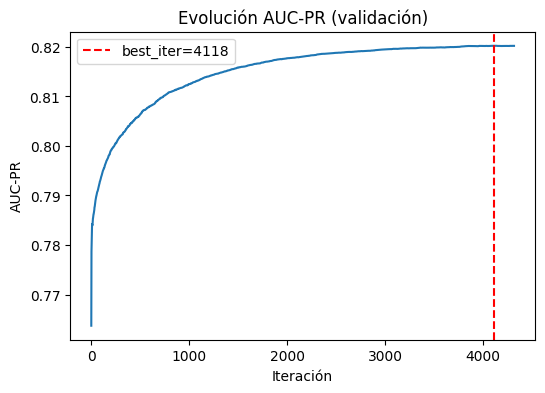

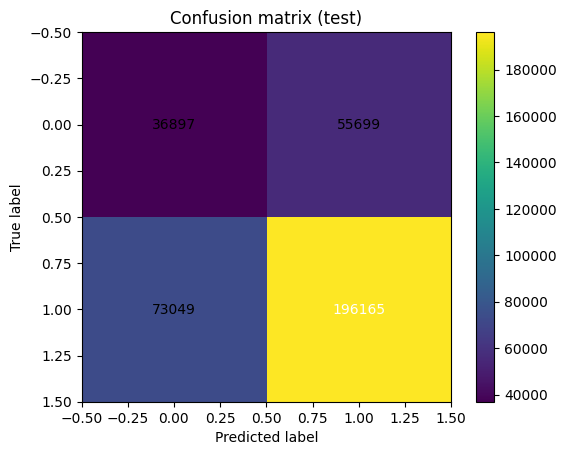

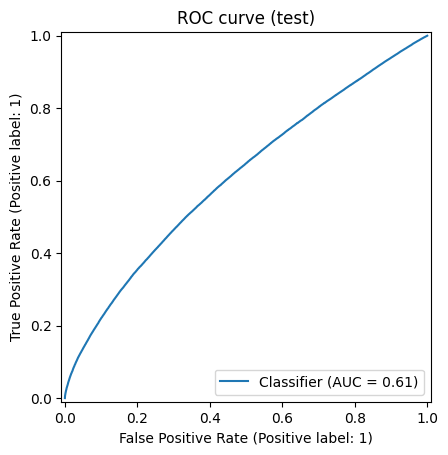

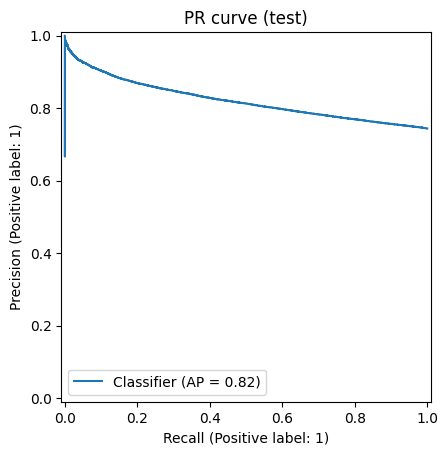

In [109]:
xgboost_params = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 5500,
            "n_jobs": -1,
            "early_stopping_rounds": 200,
            "random_state": 42,
            "verbosity": 3
        }

model, test_metrics, best_thr = train_xgboost_pipeline_cv(
    X_train = X_train.values, y_train=y_train.values,
    X_val = X_val.values, y_val=y_val.values,
    X_test = X_test.values, y_test=y_test.values,
    run_name="xgboost_baseline_cv",
    xgboost_params=xgboost_params,
    n_splits=5,
    seed=42
)

## 3.2 Optimización de hiperparámetros

### Manual y solo local

In [114]:

import xgboost as xgb
import numpy as np
import pandas as pd
import time

# 1) Desbalance SOLO del TRAIN (positiva = 1 estresado)
n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (train): {scale_pos_weight:.3f} | pos={n_pos:,} | neg={n_neg:,}")

# 2) DMatrix para API xgb.train (compatible con xgboost==3.1.2)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)


scale_pos_weight (train): 0.432 | pos=704,959 | neg=304,220


In [116]:

# Random Search de hiperparámetros con early stopping
rng = np.random.default_rng(42)

def sample_params(scale_pos_weight):
    return {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",       # mejor en desbalance
        "tree_method": "hist",        # rápido en CPU
        "seed": 42,
        "nthread": -1,
        # Hiperparámetros a buscar:
        "max_depth": int(rng.integers(5, 9)),                  # 5–8
        "eta": float(rng.uniform(0.03, 0.10)),                  # 0.03–0.10
        "subsample": float(rng.uniform(0.7, 0.9)),              # 0.7–0.9
        "colsample_bytree": float(rng.uniform(0.7, 0.9)),       # 0.7–0.9
        "min_child_weight": float(rng.uniform(2.0, 8.0)),       # 2–8
        "gamma": float(rng.uniform(0.0, 0.5)),                  # 0–0.5
        "reg_lambda": float(rng.uniform(1.0, 6.0)),             # L2
        "reg_alpha": float(rng.uniform(0.0, 0.6)),              # L1
        "max_delta_step": int(rng.integers(0, 3)),              # 0–2
        "scale_pos_weight": float(scale_pos_weight)             # fijado desde TRAIN
    }

def train_one(params, num_boost_round=1200, early_stopping_rounds=100, verbose_eval=False):
    evallist = [(dtrain, "train"), (dval, "val")]
    t0 = time.perf_counter()
    bst = xgb.train(params, dtrain, num_boost_round=num_boost_round,
                    evals=evallist, early_stopping_rounds=early_stopping_rounds,
                    verbose_eval=verbose_eval)
    elapsed = time.perf_counter() - t0
    return {
        "bst": bst,
        "score": bst.best_score,      # mejor aucpr(val)
        "best_iteration": bst.best_iteration,
        "elapsed_s": elapsed,
        "params": params
    }


In [119]:

# Ejecutar búsqueda
n_trials = 30  # ajusta según tiempo disponible
results = []
for i in range(n_trials):
    print(f"\n--- Trial {i+1}/{n_trials} ---")
    p = sample_params(scale_pos_weight)
    out = train_one(p, verbose_eval=50)
    out["trial"] = i
    results.append(out)
    print(f"[{i+1}/{n_trials}] aucpr(val)={out['score']:.4f} | best_iter={out['best_iteration']} | "
          f"eta={p['eta']:.3f} max_depth={p['max_depth']} subsample={p['subsample']:.2f} "
          f"colsample_bytree={p['colsample_bytree']:.2f} min_child_weight={p['min_child_weight']:.2f} "
          f"lambda={p['reg_lambda']:.2f} alpha={p['reg_alpha']:.2f} gamma={p['gamma']:.2f} "
          f"mds={p['max_delta_step']} | time={out['elapsed_s']:.1f}s")

# Tabla de resultados ordenada por aucpr(val)
tbl = pd.DataFrame([{
    "trial": r["trial"],
    "aucpr_val": r["score"],
    "best_iter": r["best_iteration"],
    "elapsed_s": r["elapsed_s"],
    **{k: r["params"][k] for k in [
        "eta","max_depth","subsample","colsample_bytree",
        "min_child_weight","gamma","reg_lambda","reg_alpha","max_delta_step"
    ]}
} for r in results]).sort_values("aucpr_val", ascending=False).reset_index(drop=True)

print("\nTop-10 configuraciones por AUC-PR (VALIDACIÓN):")
display(tbl.head(10))



--- Trial 1/30 ---
[0]	train-aucpr:0.74587	val-aucpr:0.76287
[50]	train-aucpr:0.78385	val-aucpr:0.78744
[100]	train-aucpr:0.79317	val-aucpr:0.79160
[150]	train-aucpr:0.80079	val-aucpr:0.79452
[200]	train-aucpr:0.80648	val-aucpr:0.79692
[250]	train-aucpr:0.81072	val-aucpr:0.79856
[300]	train-aucpr:0.81434	val-aucpr:0.79973
[350]	train-aucpr:0.81744	val-aucpr:0.80117
[400]	train-aucpr:0.82046	val-aucpr:0.80226
[450]	train-aucpr:0.82333	val-aucpr:0.80341
[500]	train-aucpr:0.82579	val-aucpr:0.80431
[550]	train-aucpr:0.82788	val-aucpr:0.80494
[600]	train-aucpr:0.82989	val-aucpr:0.80581
[650]	train-aucpr:0.83184	val-aucpr:0.80657
[700]	train-aucpr:0.83367	val-aucpr:0.80718
[750]	train-aucpr:0.83534	val-aucpr:0.80791
[800]	train-aucpr:0.83691	val-aucpr:0.80843
[850]	train-aucpr:0.83836	val-aucpr:0.80894
[900]	train-aucpr:0.83981	val-aucpr:0.80952
[950]	train-aucpr:0.84110	val-aucpr:0.80993
[1000]	train-aucpr:0.84230	val-aucpr:0.81041
[1050]	train-aucpr:0.84354	val-aucpr:0.81091
[1100]	train-

,trial,aucpr_val,best_iter,elapsed_s,eta,max_depth,subsample,colsample_bytree,min_child_weight,gamma,reg_lambda,reg_alpha,max_delta_step
0,24,0.819402,1191,521.244088,0.065443,8,0.838852,0.816223,3.198654,0.402062,4.577036,0.443390,0
1,8,0.819358,1197,55325.699088,0.058447,8,0.862804,0.733395,2.136272,0.045024,4.611797,0.277126,1
2,6,0.819025,1196,480.330262,0.068751,7,0.811841,0.760790,2.184907,0.218359,2.072923,0.245117,1
3,7,0.818830,1195,517.233285,0.046376,8,0.711661,0.756277,3.761563,0.330958,3.785161,0.470339,2
4,17,0.818731,1199,520.982306,0.068783,7,0.721715,0.834448,3.687403,0.329711,4.634973,0.461188,0
5,18,0.818666,1170,551.331644,0.094121,6,0.746043,0.707483,5.329115,0.185461,5.148949,0.484951,0
6,9,0.818628,1184,505.615070,0.065073,7,0.730462,0.839264,4.676938,0.190511,2.507560,0.378170,0
7,25,0.818617,1192,441.249296,0.038663,8,0.885513,0.779516,3.805692,0.244292,4.314321,0.573374,0
8,11,0.818473,1199,582.821179,0.080182,6,0.789872,0.754448,2.578346,0.451301,3.278881,0.121418,2
9,12,0.818449,1198,654.735402,0.070545,7,0.735355,0.871323,6.551117,0.359731,3.160465,0.376385,0


In [120]:
tbl

,trial,aucpr_val,best_iter,elapsed_s,eta,max_depth,subsample,colsample_bytree,min_child_weight,gamma,reg_lambda,reg_alpha,max_delta_step
0,24,0.819402,1191,521.244088,0.065443,8,0.838852,0.816223,3.198654,0.402062,4.577036,0.443390,0
1,8,0.819358,1197,55325.699088,0.058447,8,0.862804,0.733395,2.136272,0.045024,4.611797,0.277126,1
2,6,0.819025,1196,480.330262,0.068751,7,0.811841,0.760790,2.184907,0.218359,2.072923,0.245117,1
3,7,0.818830,1195,517.233285,0.046376,8,0.711661,0.756277,3.761563,0.330958,3.785161,0.470339,2
4,17,0.818731,1199,520.982306,0.068783,7,0.721715,0.834448,3.687403,0.329711,4.634973,0.461188,0
5,18,0.818666,1170,551.331644,0.094121,6,0.746043,0.707483,5.329115,0.185461,5.148949,0.484951,0
6,9,0.818628,1184,505.615070,0.065073,7,0.730462,0.839264,4.676938,0.190511,2.507560,0.378170,0
7,25,0.818617,1192,441.249296,0.038663,8,0.885513,0.779516,3.805692,0.244292,4.314321,0.573374,0
8,11,0.818473,1199,582.821179,0.080182,6,0.789872,0.754448,2.578346,0.451301,3.278881,0.121418,2
9,12,0.818449,1198,654.735402,0.070545,7,0.735355,0.871323,6.551117,0.359731,3.160465,0.376385,0


### MLflow + optuna

In [110]:
def train_eval_trial_xgboost(
    X_train, y_train,
    X_val,   y_val,
    xgb_params,
    trial=None,
    seed=42,
    verbose=False
):
    np.random.seed(seed)

    # -----------------------------
    # scale_pos_weight (fijo)
    # -----------------------------
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)

    xgb_params = xgb_params.copy()
    xgb_params["scale_pos_weight"] = scale_pos_weight
    xgb_params["random_state"] = seed

    # -----------------------------
    # Pipeline
    # -----------------------------
    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("xgb", XGBClassifier(**xgb_params))
    ])

    # -----------------------------
    # Fit manual (por early stopping)
    # -----------------------------
    model.named_steps["scaler"].fit(X_train)

    X_train_s = model.named_steps["scaler"].transform(X_train)
    X_val_s   = model.named_steps["scaler"].transform(X_val)

    model.named_steps["xgb"].fit(
        X_train_s, y_train,
        eval_set=[(X_val_s, y_val)],
        verbose=False
    )

    # -----------------------------
    # Validación
    # -----------------------------
    y_prob_val = model.named_steps["xgb"].predict_proba(X_val_s)[:, 1]

    pr_auc  = average_precision_score(y_val, y_prob_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)

    y_pred = (y_prob_val >= 0.5).astype(int)

    metrics = {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred),
        "best_iteration": model.named_steps["xgb"].best_iteration
    }

    # -----------------------------
    # Optuna prune
    # -----------------------------
    if trial is not None:
        trial.report(pr_auc, step=metrics["best_iteration"])
        if trial.should_prune():
            raise optuna.TrialPruned()

    if verbose:
        print(
            f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
            f"F1={metrics['f1_macro']:.4f} | "
            f"best_iter={metrics['best_iteration']}"
        )

    return metrics


In [111]:
def run_optuna_xgboost(
    X_train, y_train,
    X_val,   y_val,
    n_trials=30,
    seed=42
):
    with mlflow.start_run(run_name="optuna_xgboost"):

        def objective(trial):

            # -------------------------
            # Hiperparámetros Optuna
            # -------------------------
            xgb_params = {
                "objective": "binary:logistic",
                "eval_metric": "aucpr",
                "tree_method": "hist",
                "n_jobs": -1,
                "verbosity": 0,

                "max_depth": trial.suggest_int("max_depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

                "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
                "gamma": trial.suggest_float("gamma", 0.0, 5.0),

                "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),

                # margen amplio para early stopping
                "n_estimators": 4000,
                "early_stopping_rounds": 100
            }

            try:
                with mlflow.start_run(
                    run_name=f"xgb_trial_{trial.number}",
                    nested=True
                ):
                    # -------------------------
                    # Log params
                    # -------------------------
                    mlflow.log_params(xgb_params)

                    # -------------------------
                    # Train + VAL
                    # -------------------------
                    metrics = train_eval_trial_xgboost(
                        X_train=X_train, y_train=y_train,
                        X_val=X_val,     y_val=y_val,
                        xgb_params=xgb_params,
                        trial=trial,
                        verbose=True
                    )

                    # -------------------------
                    # Log metrics
                    # -------------------------
                    mlflow.log_metrics(metrics)
                    mlflow.log_param("trial_status", "completed")

                    return metrics["pr_auc"]

            except optuna.TrialPruned:
                mlflow.log_param("trial_status", "pruned")
                raise

            except Exception as e:
                mlflow.log_param("trial_status", "failed_exception")
                print(f"❌ Trial {trial.number} failed: {e}")
                return None

        # -------------------------
        # Optuna study
        # -------------------------
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
            pruner=optuna.pruners.MedianPruner(
                n_startup_trials=5,
                n_warmup_steps=10
            )
        )

        study.optimize(objective, n_trials=n_trials)

        # -------------------------
        # Log best
        # -------------------------
        mlflow.log_metric("best_val_pr_auc", study.best_value)
        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})

        print("Best PR-AUC:", study.best_value)
        print("Best params:", study.best_params)

        return study


In [112]:
study = run_optuna_xgboost(
    X_train = X_train.values, y_train=y_train.values,
    X_val = X_val.values, y_val=y_val.values,
    n_trials=30,
    seed=42
)

best_params_optuna = study.best_params

print(best_params_optuna)

[I 2026-01-09 10:39:58,717] A new study created in memory with name: no-name-47ebe82a-4d1d-4d85-b6e7-6ba07c70f0dd


PR-AUC=0.8173 | ROC-AUC=0.6294 | F1=0.5606 | best_iter=824
🏃 View run xgb_trial_0 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/7d325a7d5555418785337ed2d9508ec5
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


[I 2026-01-09 10:41:55,061] Trial 0 finished with value: 0.8173254902345132 and parameters: {'max_depth': 6, 'learning_rate': 0.17254716573280354, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2.4041677639819286, 'gamma': 0.7799726016810132, 'reg_alpha': 2.231010801867921e-06, 'reg_lambda': 1.156732719914599}. Best is trial 0 with value: 0.8173254902345132.


PR-AUC=0.8174 | ROC-AUC=0.6295 | F1=0.5616 | best_iter=869


[I 2026-01-09 10:44:07,002] Trial 1 finished with value: 0.8173782537714767 and parameters: {'max_depth': 8, 'learning_rate': 0.08341106432362087, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 8.491983767203795, 'gamma': 1.0616955533913808, 'reg_alpha': 1.2329623163659841e-05, 'reg_lambda': 1.922346047064365e-05}. Best is trial 1 with value: 0.8173782537714767.


...

PR-AUC=0.8192 | ROC-AUC=0.6326 | F1=0.5607 | best_iter=3937
🏃 View run xgb_trial_28 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/dd7eff7a2d714f4ea828d470025536cf
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


[I 2026-01-09 15:14:54,622] Trial 28 finished with value: 0.8191855932152168 and parameters: {'max_depth': 7, 'learning_rate': 0.023631612640429168, 'subsample': 0.9313735623281718, 'colsample_bytree': 0.863768624224984, 'min_child_weight': 4.379761175852357, 'gamma': 2.7004720057958163, 'reg_alpha': 0.03323203004922789, 'reg_lambda': 2.1818016842666523}. Best is trial 18 with value: 0.8206248994505629.


PR-AUC=0.8203 | ROC-AUC=0.6342 | F1=0.5635 | best_iter=3429


[I 2026-01-09 15:22:23,340] Trial 29 finished with value: 0.8202594422178804 and parameters: {'max_depth': 6, 'learning_rate': 0.037731224024453926, 'subsample': 0.87338720277801, 'colsample_bytree': 0.9525189131114024, 'min_child_weight': 2.268913590289772, 'gamma': 0.7776845615266534, 'reg_alpha': 6.34278992678242e-06, 'reg_lambda': 0.4873921707355708}. Best is trial 18 with value: 0.8206248994505629.


🏃 View run xgb_trial_29 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/f26ffabbea0a42fd9245ff636758725d
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3
Best PR-AUC: 0.8206248994505629
Best params: {'max_depth': 8, 'learning_rate': 0.028537584377378997, 'subsample': 0.826600824178393, 'colsample_bytree': 0.7539607086772941, 'min_child_weight': 4.924898502150522, 'gamma': 1.6214678216883898, 'reg_alpha': 0.0312847591640441, 'reg_lambda': 9.268367239048338}
🏃 View run optuna_xgboost at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/8749821459d748ebbf87e41e03dcac54
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3
{'max_depth': 8, 'learning_rate': 0.028537584377378997, 'subsample': 0.826600824178393, 'colsample_bytree': 0.7539607086772941, 'min_child_weight': 4.924898502150522, 'gamma': 1.6214678216883898, 'reg_alpha': 0.0312847591640441, 'reg_lambda': 9.268367239048338}


### Entrenamiento modelo final

In [113]:
xgboost_params_final = {
            "objective": "binary:logistic",
            "max_depth": 6,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "max_delta_step": 1,
            "tree_method": "hist",
            "n_estimators": 5500,
            "n_jobs": -1,
            "early_stopping_rounds": 200,
            "random_state": 42,
            "verbosity": 0
        }

xgboost_params_final.update(best_params_optuna)

xgboost_params_final

{'objective': 'binary:logistic',
 'max_depth': 8,
 'learning_rate': 0.028537584377378997,
 'subsample': 0.826600824178393,
 'colsample_bytree': 0.7539607086772941,
 'eval_metric': 'aucpr',
 'max_delta_step': 1,
 'tree_method': 'hist',
 'n_estimators': 5500,
 'n_jobs': -1,
 'early_stopping_rounds': 200,
 'random_state': 42,
 'verbosity': 0,
 'min_child_weight': 4.924898502150522,
 'gamma': 1.6214678216883898,
 'reg_alpha': 0.0312847591640441,
 'reg_lambda': 9.268367239048338}

Ejecutando Cross-Validation
[0]	validation_0-aucpr:0.76602
[1]	validation_0-aucpr:0.77954
[2]	validation_0-aucpr:0.78258
[3]	validation_0-aucpr:0.78319
[4]	validation_0-aucpr:0.78531
[5]	validation_0-aucpr:0.78494
[6]	validation_0-aucpr:0.78647
[7]	validation_0-aucpr:0.78761
[8]	validation_0-aucpr:0.78810
[9]	validation_0-aucpr:0.78836
[10]	validation_0-aucpr:0.78842
[11]	validation_0-aucpr:0.78866
[12]	validation_0-aucpr:0.78912
[13]	validation_0-aucpr:0.78922
[14]	validation_0-aucpr:0.78921
[15]	validation_0-aucpr:0.78935
[16]	validation_0-aucpr:0.78929
[17]	validation_0-aucpr:0.78951
[18]	validation_0-aucpr:0.78936
[19]	validation_0-aucpr:0.78967
[20]	validation_0-aucpr:0.78996
[21]	validation_0-aucpr:0.79000
[22]	validation_0-aucpr:0.79030
[23]	validation_0-aucpr:0.79061
[24]	validation_0-aucpr:0.79079
[25]	validation_0-aucpr:0.79097
[26]	validation_0-aucpr:0.79101
[27]	validation_0-aucpr:0.79127
[28]	validation_0-aucpr:0.79137
[29]	validation_0-aucpr:0.79133
[30]	validation_0-aucp

Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/09 17:10:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 26
Created version '26' of model 'bean_stress_classifier'.


🏃 View run xgboost_cv_final_model at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3/runs/c9156f9c3e424313bb50051d249082b9
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/3


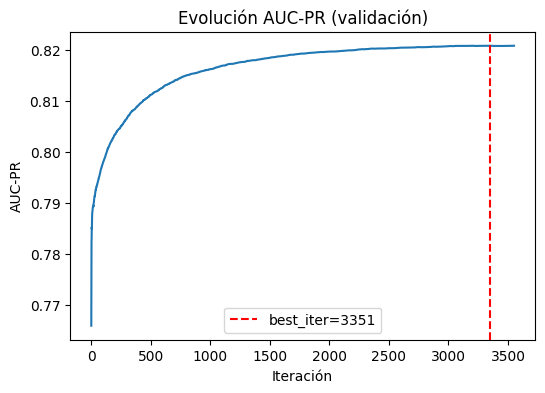

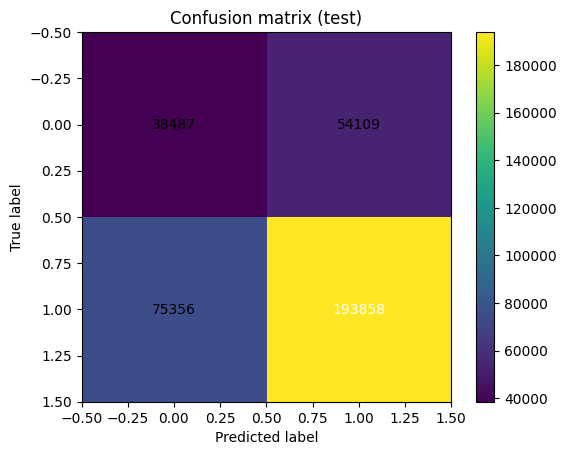

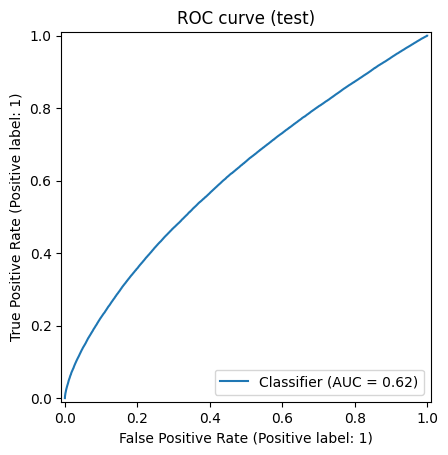

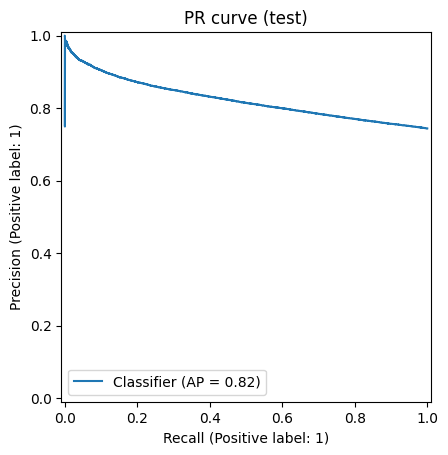

In [115]:
model, test_metrics, best_thr = train_xgboost_pipeline_cv(
    X_train = X_train.values, y_train=y_train.values,
    X_val = X_val.values, y_val=y_val.values,
    X_test = X_test.values, y_test=y_test.values,
    run_name="xgboost_cv_final_model",
    xgboost_params=xgboost_params_final,
    n_splits=5,
    seed=42
)

# 4. Modelado con SGDClassifier

## 4.1 Modelo sin optimización de hiperparámetros

In [91]:
mlflow.set_experiment("sgdclassifier")

<Experiment: artifact_location='mlflow-artifacts:/2f21fede80f047cbbdf976562898ab89', creation_time=1768228992024, experiment_id='5', last_update_time=1768228992024, lifecycle_stage='active', name='sgdclassifier', tags={'mlflow.experimentKind': 'custom_model_development'}>

### MLlfow + CV

In [92]:
def train_sgd_pipeline_cv(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="sgd_baseline_cv",
        sgd_params=None,
        n_splits=5,
        seed=42
    ):

    figs_path = PathManager().get_abs_path_folder("figures")
    models_path = PathManager().get_abs_path_folder("models")
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # =============================
    # Default params
    # =============================
    if sgd_params is None:
        sgd_params = {
            "loss": "log_loss",
            "penalty": "l2",
            "alpha": 1e-4,
            "max_iter": 1000,
            "tol": 1e-3,
            "class_weight": "balanced",
            "random_state": seed,
            "n_jobs": -1
        }

    # =============================
    # MLflow
    # =============================
    with mlflow.start_run(run_name=run_name):

        mlflow.log_params(sgd_params)
        mlflow.log_param("cv_folds", n_splits)
        mlflow.log_param("uses_pipeline_scaler", True)
        mlflow.log_param("model_type", "SGDClassifier")

        # =============================
        # 1️⃣ Cross-Validation (TRAIN only)
        # =============================
        print("Ejecutando Cross-Validation (SGD)")

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )

        cv_scores = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):

            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]

            model_fold = Pipeline(steps=[
                ("scaler", RobustScaler()),
                ("sgd", SGDClassifier(**sgd_params))
            ])

            model_fold.fit(X_tr, y_tr)

            y_prob_va = model_fold.predict_proba(X_va)[:, 1]
            pr_auc = average_precision_score(y_va, y_prob_va)

            cv_scores.append(pr_auc)
            mlflow.log_metric(f"cv_fold_{fold}_pr_auc", pr_auc)

        mean_cv_pr = float(np.mean(cv_scores))
        std_cv_pr  = float(np.std(cv_scores))

        mlflow.log_metric("cv_mean_pr_auc", mean_cv_pr)
        mlflow.log_metric("cv_std_pr_auc", std_cv_pr)

        best_fold = int(np.argmax(cv_scores))
        mlflow.log_param("best_cv_fold", best_fold + 1)

        # =============================
        # 2️⃣ Final training (TRAIN + VAL)
        # =============================
        model = Pipeline(steps=[
            ("scaler", RobustScaler()),
            ("sgd", SGDClassifier(**sgd_params))
        ])

        model.fit(X_train, y_train)

        # =============================
        # 3️⃣ Threshold tuning (VAL)
        # =============================
        y_prob_val = model.predict_proba(X_val)[:, 1]

        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro"))
             for t in thr_grid),
            key=lambda x: x[1])
        
        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        # =============================
        # 4️⃣ TEST evaluation
        # =============================
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # =============================
        # Confusion matrix
        # =============================
        cm = confusion_matrix(y_test, y_pred_test)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_path = figs_path + f"confusion_matrix_{run_name}.png"
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # ============================
        # ROC & PR curves
        # ============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        artifact_name = f"roc_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        artifact_name = f"pr_curve_{run_name}.png"
        artifact_path = figs_path + artifact_name
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # =============================
        # Save model
        # =============================
        joblib.dump(model, models_path + f"{run_name}.pkl")

        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr


Ejecutando Cross-Validation (SGD)
Umbral óptimo VAL: 0.455 | F1_macro=0.544


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 09:57:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 27
Created version '27' of model 'bean_stress_classifier'.


🏃 View run sgd_baseline_cv at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/93e4d42902a342369e04ea49700aea92
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5


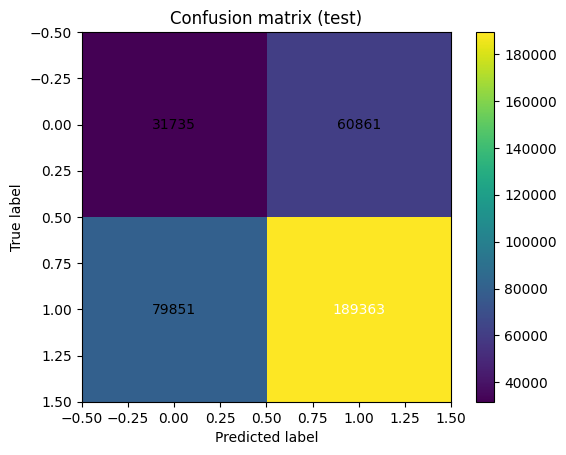

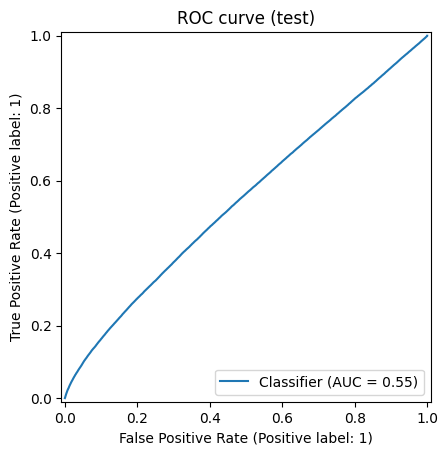

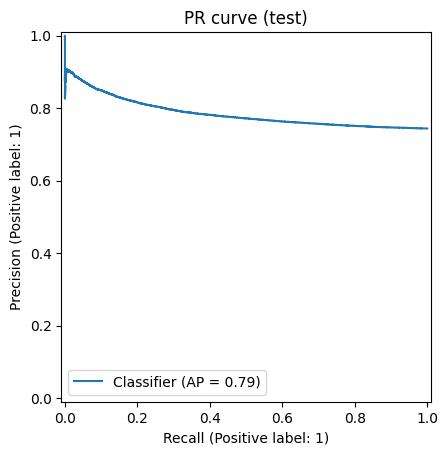

In [85]:
sgd_params = {
    "loss": "log_loss",          # equivalente a logistic regression
    "penalty": "l2",
    "alpha": 1e-4,               # regularización
    "learning_rate": "optimal",
    "eta0": 0.0,                 # ignorado si learning_rate='optimal'
    "max_iter": 2000,
    "tol": 1e-3,
    "class_weight": "balanced",  # MUY importante en tu caso
    "random_state": 42,
    "n_jobs": -1
}

model, test_metrics, best_thr = train_sgd_pipeline_cv(
    X_train=X_train.values,
    y_train=y_train.values,
    X_val=X_val.values,
    y_val=y_val.values,
    X_test=X_test.values,
    y_test=y_test.values,
    run_name="sgd_baseline_cv",
    sgd_params=sgd_params,
    n_splits=5,
    seed=42
)



## 4.2 Optimización de hiperparámetros

### MLflow + CV + optuna

In [93]:
def train_eval_trial_sgd(
    X_train, y_train,
    X_val,   y_val,
    sgd_params,
    trial=None,
    seed=42,
    verbose=False
):
    np.random.seed(seed)

    # -----------------------------
    # Pipeline
    # -----------------------------
    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("sgd", SGDClassifier(**sgd_params))
    ])

    # -----------------------------
    # Fit
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # Validation
    # -----------------------------
    y_prob_val = model.predict_proba(X_val)[:, 1]

    pr_auc  = average_precision_score(y_val, y_prob_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)

    y_pred = (y_prob_val >= 0.5).astype(int)

    metrics = {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred),
    }

    # -----------------------------
    # Optuna prune
    # -----------------------------
    if trial is not None:
        trial.report(pr_auc, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

    if verbose:
        print(
            f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
            f"F1={metrics['f1_macro']:.4f}"
        )

    return metrics


In [95]:
def run_optuna_sgd(
    X_train, y_train,
    X_val,   y_val,
    n_trials=30,
    seed=42
):
    with mlflow.start_run(run_name="optuna_sgd_classifier"):

        def objective(trial):

            # -------------------------
            # Hyperparameters
            # -------------------------
            loss = trial.suggest_categorical(
                "loss", ["log_loss", "modified_huber"]
            )

            penalty = trial.suggest_categorical(
                "penalty", ["l2", "l1", "elasticnet"]
            )

            l1_ratio = None
            if penalty == "elasticnet":
                l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

            learning_rate = trial.suggest_categorical(
                "learning_rate", ["optimal", "adaptive"]
            )

            sgd_params = {
                "loss": loss,
                "penalty": penalty,
                "alpha": trial.suggest_float("alpha", 1e-6, 1e-2, log=True),
                "learning_rate": learning_rate,
                "eta0": trial.suggest_float("eta0", 1e-4, 1e-1, log=True),
                "max_iter": trial.suggest_int("max_iter", 500, 3000),
                "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
                "class_weight": "balanced",
                "random_state": seed,
                "n_jobs": -1
            }

            if l1_ratio is not None:
                sgd_params["l1_ratio"] = l1_ratio

            try:
                with mlflow.start_run(
                    run_name=f"sgd_trial_{trial.number}",
                    nested=True
                ):
                    # -------------------------
                    # Log params
                    # -------------------------
                    mlflow.log_params(sgd_params)

                    # -------------------------
                    # Train + VAL
                    # -------------------------
                    metrics = train_eval_trial_sgd(
                        X_train=X_train, y_train=y_train,
                        X_val=X_val,     y_val=y_val,
                        sgd_params=sgd_params,
                        trial=trial,
                        verbose=True
                    )

                    # -------------------------
                    # Log metrics
                    # -------------------------
                    mlflow.log_metrics(metrics)
                    mlflow.log_param("trial_status", "completed")

                    return metrics["pr_auc"]

            except optuna.TrialPruned:
                mlflow.log_param("trial_status", "pruned")
                raise

            except Exception as e:
                mlflow.log_param("trial_status", "failed_exception")
                print(f"❌ Trial {trial.number} failed: {e}")
                return None

        # -------------------------
        # Optuna study
        # -------------------------
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
            pruner=optuna.pruners.MedianPruner(
                n_startup_trials=5
            )
        )

        study.optimize(objective, n_trials=n_trials)

        # -------------------------
        # Log best
        # -------------------------
        mlflow.log_metric("best_val_pr_auc", study.best_value)
        mlflow.log_params(
            {f"best_{k}": v for k, v in study.best_params.items()}
        )

        print("Best PR-AUC:", study.best_value)
        print("Best params:", study.best_params)

        return study


In [96]:
study_sgd = run_optuna_sgd(
    X_train=X_train.values, y_train=y_train.values,
    X_val=X_val.values,     y_val=y_val.values,
    n_trials=15,
    seed=42
)

best_sgd_params = study_sgd.best_params


[I 2026-01-12 17:10:15,572] A new study created in memory with name: no-name-4bc97df3-3c40-49eb-8b36-b4a2bf89e344


PR-AUC=0.7897 | ROC-AUC=0.5819 | F1=0.5209


[I 2026-01-12 17:10:27,185] Trial 0 finished with value: 0.7897035487147332 and parameters: {'loss': 'modified_huber', 'penalty': 'l2', 'learning_rate': 'optimal', 'alpha': 0.0029154431891537554, 'eta0': 0.006358358856676255, 'max_iter': 2270, 'tol': 0.00010994335574766199}. Best is trial 0 with value: 0.7897035487147332.


🏃 View run sgd_trial_0 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/9ea5a835e10d465c82a7522676e76365
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5
PR-AUC=0.7923 | ROC-AUC=0.5829 | F1=0.5246


[I 2026-01-12 17:10:48,986] Trial 1 finished with value: 0.7923314031390156 and parameters: {'loss': 'log_loss', 'penalty': 'l2', 'learning_rate': 'adaptive', 'alpha': 5.34293726127978e-05, 'eta0': 0.0007476312062252305, 'max_iter': 2030, 'tol': 0.00019010245319870352}. Best is trial 1 with value: 0.7923314031390156.


...

🏃 View run sgd_trial_12 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/b8dfdc07d8894f3395b8d7be7ddb3a4f
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5
PR-AUC=0.7928 | ROC-AUC=0.5829 | F1=0.5255


[I 2026-01-12 17:17:16,986] Trial 13 finished with value: 0.7927885276003577 and parameters: {'loss': 'log_loss', 'penalty': 'l1', 'learning_rate': 'adaptive', 'alpha': 1.348675745528618e-05, 'eta0': 0.09360471349194453, 'max_iter': 1438, 'tol': 0.0002846282635669909}. Best is trial 10 with value: 0.7928125965192481.


🏃 View run sgd_trial_13 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/e48dcec3396243a2b42b4af7571598da
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5
🏃 View run sgd_trial_14 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/72a744846d9b4537828b065229e692d4
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5


[I 2026-01-12 17:17:43,942] Trial 14 pruned. 


Best PR-AUC: 0.7928125965192481
Best params: {'loss': 'log_loss', 'penalty': 'l1', 'learning_rate': 'adaptive', 'alpha': 2.4400771927662253e-05, 'eta0': 0.07805212148154592, 'max_iter': 1360, 'tol': 0.0003242551761422182}
🏃 View run optuna_sgd_classifier at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/82dcaf57adab40748c4b44da0e1c87ec
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5


### Entrenamiento modelo final

In [99]:
sgd_params_final = {
    "loss": "log_loss",          # equivalente a logistic regression
    "penalty": "l2",
    "alpha": 1e-4,               # regularización
    "learning_rate": "optimal",
    "eta0": 0.0,                 # ignorado si learning_rate='optimal'
    "max_iter": 2000,
    "tol": 1e-3,
    "class_weight": "balanced",  # MUY importante en tu caso
    "random_state": 42,
    "n_jobs": -1
}

sgd_params_final.update(best_sgd_params)

sgd_params_final

{'loss': 'log_loss',
 'penalty': 'l1',
 'alpha': 2.4400771927662253e-05,
 'learning_rate': 'adaptive',
 'eta0': 0.07805212148154592,
 'max_iter': 1360,
 'tol': 0.0003242551761422182,
 'class_weight': 'balanced',
 'random_state': 42,
 'n_jobs': -1}

Ejecutando Cross-Validation (SGD)
Umbral óptimo VAL: 0.435 | F1_macro=0.542


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 17:25:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 33
Created version '33' of model 'bean_stress_classifier'.


🏃 View run sgd_cv_final_model at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5/runs/cb6d38bef25648658db3bffc3e31836b
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/5


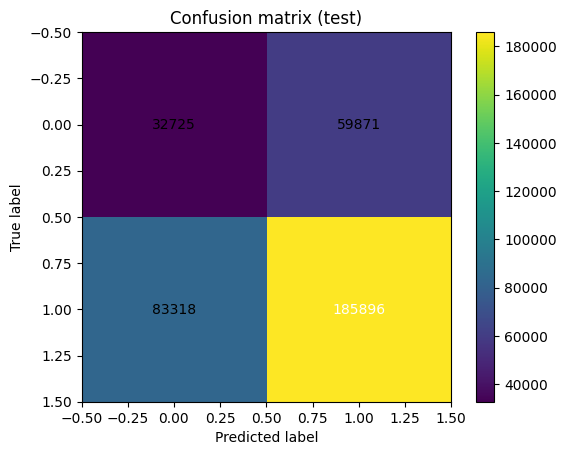

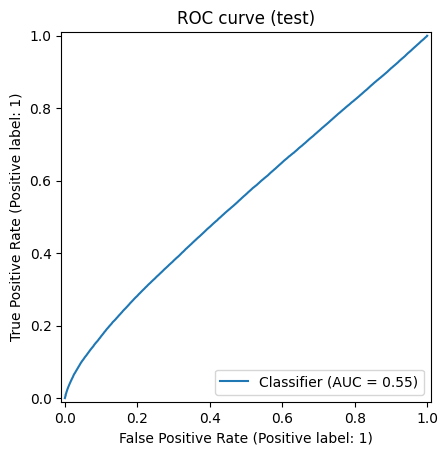

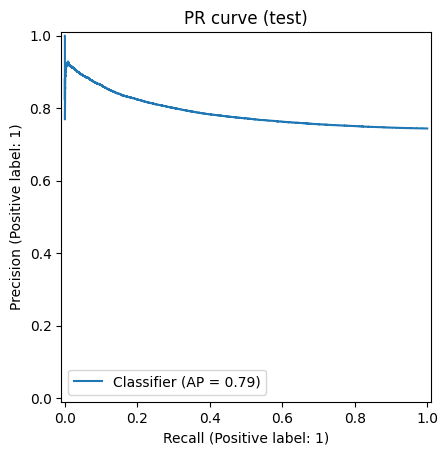

In [100]:
model, test_metrics, best_thr = train_sgd_pipeline_cv(
    X_train=X_train.values,
    y_train=y_train.values,
    X_val=X_val.values,
    y_val=y_val.values,
    X_test=X_test.values,
    y_test=y_test.values,
    run_name="sgd_cv_final_model",
    sgd_params=sgd_params_final,
    n_splits=5,
    seed=42
)

# 5. Modelado con LGBMClassifier

## 5.1 Modelo sin optimización de hiperparámetros

In [80]:
mlflow.set_experiment("lgbmclassifier")

<Experiment: artifact_location='mlflow-artifacts:/dbbebbc2c1d3438e8c7c527a92c3606f', creation_time=1768231248601, experiment_id='6', last_update_time=1768231248601, lifecycle_stage='active', name='lgbmclassifier', tags={'mlflow.experimentKind': 'custom_model_development'}>

### MLlfow + CV

In [96]:
def train_lgbm_pipeline_cv(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="lgbm_baseline_cv",
        lgbm_params=None,
        n_splits=5,
        seed=42
    ):

    figs_path = PathManager().get_abs_path_folder("figures")
    models_path = PathManager().get_abs_path_folder("models")
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # =============================
    # scale_pos_weight
    # =============================
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)

    # =============================
    # Default params
    # =============================
    if lgbm_params is None:
        lgbm_params = {
            "objective": "binary",
            "eval_metric": "average_precision",
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "n_estimators": 2000,
            "scale_pos_weight": scale_pos_weight,
            "random_state": seed,
            "n_jobs": -1,
            "verbosity": -1
        }
    else:
        lgbm_params.setdefault("scale_pos_weight", scale_pos_weight)

    # =============================
    # MLflow
    # =============================
    with mlflow.start_run(run_name=run_name):

        mlflow.log_params(lgbm_params)
        mlflow.log_param("cv_folds", n_splits)
        mlflow.log_param("uses_pipeline_scaler", True)
        mlflow.log_param("model_type", "LGBMClassifier")

        # =============================
        # 1️⃣ Cross-Validation (TRAIN only)
        # =============================
        print("Ejecutando Cross-Validation (LGBM)")

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )

        cv_scores = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):

            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]

            lgbm_params_cv = lgbm_params.copy()
            lgbm_params_cv["n_estimators"] = 1500

            model_fold = Pipeline(steps=[
                ("scaler", RobustScaler()),
                ("lgbm", LGBMClassifier(**lgbm_params_cv))
            ])

            scaler = model_fold.named_steps["scaler"]
            X_tr_s = scaler.fit_transform(X_tr)
            X_va_s = scaler.transform(X_va)

            lgbm_fold = model_fold.named_steps["lgbm"]

            lgbm_fold.fit(
                X_tr_s, y_tr,
                eval_set=[(X_va_s, y_va)],
                callbacks=[lgbm.early_stopping(100, verbose=False)]
            )

            y_prob_va = lgbm_fold.predict_proba(X_va_s)[:, 1]
            pr_auc = average_precision_score(y_va, y_prob_va)

            cv_scores.append(pr_auc)
            mlflow.log_metric(f"cv_fold_{fold}_pr_auc", pr_auc)

        mean_cv_pr = float(np.mean(cv_scores))
        std_cv_pr  = float(np.std(cv_scores))

        mlflow.log_metric("cv_mean_pr_auc", mean_cv_pr)
        mlflow.log_metric("cv_std_pr_auc", std_cv_pr)

        best_fold = int(np.argmax(cv_scores))
        mlflow.log_param("best_cv_fold", best_fold + 1)

        # =============================
        # 2️⃣ Final training (TRAIN + VAL)
        # =============================
        model = Pipeline(steps=[
            ("scaler", RobustScaler()),
            ("lgbm", LGBMClassifier(**lgbm_params))
        ])

        scaler = model.named_steps["scaler"]
        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)

        lgbm_final = model.named_steps["lgbm"]

        lgbm_final.fit(
            X_train_s, y_train,
            eval_set=[(X_val_s, y_val)],
            eval_metric="average_precision",
            callbacks=[lgbm.early_stopping(200, verbose=True)]
        )

        # =============================
        # 3️⃣ Threshold tuning (VAL)
        # =============================
        y_prob_val = lgbm_final.predict_proba(X_val_s)[:, 1]

        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro"))
             for t in thr_grid),
            key=lambda x: x[1]
        )

        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        # =============================
        # 4️⃣ TEST evaluation
        # =============================
        X_test_s = scaler.transform(X_test)
        y_prob_test = lgbm_final.predict_proba(X_test_s)[:, 1]
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # =============================
        # Confusion matrix
        # =============================
        cm = confusion_matrix(y_test, y_pred_test)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j],
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_path = figs_path + f"confusion_matrix_{run_name}.png"
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # =============================
        # ROC & PR curves
        # =============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        plt.savefig(figs_path + f"roc_curve_{run_name}.png")
        mlflow.log_artifact(figs_path + f"roc_curve_{run_name}.png")

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        plt.savefig(figs_path + f"pr_curve_{run_name}.png")
        mlflow.log_artifact(figs_path + f"pr_curve_{run_name}.png")

        # =============================
        # Save model
        # =============================
        joblib.dump(model, models_path + f"{run_name}.pkl")

        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr


Ejecutando Cross-Validation (LGBM)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.771823	valid_0's binary_logloss: 0.587287
Umbral óptimo VAL: 0.695 | F1_macro=0.456


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 10:38:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 29
Created version '29' of model 'bean_stress_classifier'.


🏃 View run lgbm_baseline_cv at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/21ebee9ba9e7444fbb3189be5217af1c
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6


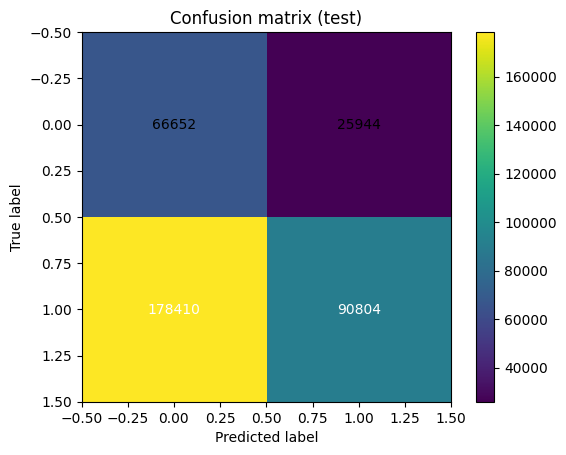

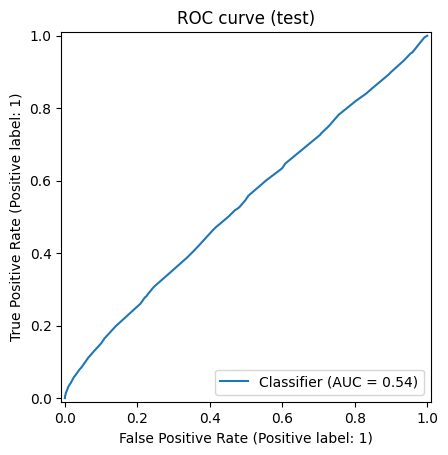

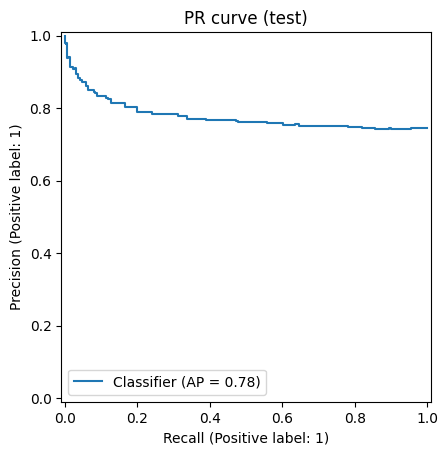

In [97]:
lgbm_params = {
            "objective": "binary",
            "eval_metric": "average_precision",
            "learning_rate": 0.02,
            "num_leaves": 63,
            "max_depth": -1,
            "subsample": 0.8,
            "min_child_samples": 50,
            "min_split_gain": 0.0,
            "colsample_bytree": 0.8,
            "n_estimators": 3000,
            "random_state": 42,
            "n_jobs": -1,
            "verbosity": -1
        }

model, test_metrics, best_thr = train_lgbm_pipeline_cv(
    X_train=X_train.values,
    y_train=y_train.values,
    X_val=X_val.values,
    y_val=y_val.values,
    X_test=X_test.values,
    y_test=y_test.values,
    run_name="lgbm_baseline_cv",
    lgbm_params=lgbm_params,
    n_splits=5,
    seed=42
)


## 5.2 Optimización de hiperparámetros

### MLflow + Optuna

In [87]:
def train_eval_trial_lgbm(
    X_train, y_train,
    X_val,   y_val,
    lgbm_params,
    trial=None,
    seed=42,
    verbose=False
):
    np.random.seed(seed)

    # -----------------------------
    # class_weight (equivalente a scale_pos_weight)
    # -----------------------------
    n_pos = int(np.sum(y_train == 1))
    n_neg = int(np.sum(y_train == 0))
    scale_pos_weight = n_neg / max(n_pos, 1)

    lgbm_params = lgbm_params.copy()
    lgbm_params["scale_pos_weight"] = scale_pos_weight
    lgbm_params["random_state"] = seed

    # -----------------------------
    # Pipeline
    # -----------------------------
    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("lgb", LGBMClassifier(**lgbm_params))
    ])

    # -----------------------------
    # Fit manual (early stopping)
    # -----------------------------
    scaler = model.named_steps["scaler"]
    scaler.fit(X_train)

    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)

    lgb = model.named_steps["lgb"]

    lgb.fit(
        X_train_s, y_train,
        eval_set=[(X_val_s, y_val)],
        callbacks=[
            lgbm.early_stopping(
                stopping_rounds=lgbm_params["early_stopping_rounds"],
                verbose=False
            )
        ]
    )

    # -----------------------------
    # Validación
    # -----------------------------
    y_prob_val = lgb.predict_proba(X_val_s)[:, 1]

    pr_auc  = average_precision_score(y_val, y_prob_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)

    y_pred = (y_prob_val >= 0.5).astype(int)

    metrics = {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred),
        "best_iteration": lgb.best_iteration_
    }

    # -----------------------------
    # Optuna prune
    # -----------------------------
    if trial is not None:
        trial.report(pr_auc, step=metrics["best_iteration"])
        if trial.should_prune():
            raise optuna.TrialPruned()

    if verbose:
        print(
            f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
            f"F1={metrics['f1_macro']:.4f} | "
            f"best_iter={metrics['best_iteration']}"
        )

    return metrics


In [92]:
def run_optuna_lgbm(
    X_train, y_train,
    X_val,   y_val,
    n_trials=30,
    seed=42
):
    with mlflow.start_run(run_name="optuna_lgbm"):

        def objective(trial):

            # -------------------------
            # Hiperparámetros Optuna
            # -------------------------
            lgbm_params = {
                "objective": "binary",
                "eval_metric": "average_precision",
                "boosting_type": "gbdt",
                "verbosity": -1,
                "n_jobs": -1,

                "learning_rate": trial.suggest_float(
                    "learning_rate", 0.01, 0.2, log=True
                ),

                "num_leaves": trial.suggest_int(
                    "num_leaves", 16, 128
                ),

                "max_depth": trial.suggest_int(
                    "max_depth", 3, 12
                ),

                "min_child_samples": trial.suggest_int(
                    "min_child_samples", 10, 100
                ),

                "subsample": trial.suggest_float(
                    "subsample", 0.6, 1.0
                ),

                "colsample_bytree": trial.suggest_float(
                    "colsample_bytree", 0.6, 1.0
                ),

                "reg_alpha": trial.suggest_float(
                    "reg_alpha", 1e-6, 1.0, log=True
                ),

                "reg_lambda": trial.suggest_float(
                    "reg_lambda", 1e-6, 10.0, log=True
                ),

                # margen amplio para early stopping
                "n_estimators": 4000,
                "early_stopping_rounds": 100
            }

            try:
                with mlflow.start_run(
                    run_name=f"lgbm_trial_{trial.number}",
                    nested=True
                ):
                    # -------------------------
                    # Log params
                    # -------------------------
                    mlflow.log_params(lgbm_params)

                    # -------------------------
                    # Train + VAL
                    # -------------------------
                    metrics = train_eval_trial_lgbm(
                        X_train=X_train, y_train=y_train,
                        X_val=X_val,     y_val=y_val,
                        lgbm_params=lgbm_params,
                        trial=trial,
                        verbose=True
                    )

                    # -------------------------
                    # Log metrics
                    # -------------------------
                    mlflow.log_metrics(metrics)
                    mlflow.log_param("trial_status", "completed")

                    return metrics["pr_auc"]

            except optuna.TrialPruned:
                mlflow.log_param("trial_status", "pruned")
                raise

            except Exception as e:
                mlflow.log_param("trial_status", "failed_exception")
                print(f"❌ Trial {trial.number} failed: {e}")
                return None

        # -------------------------
        # Optuna study
        # -------------------------
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
            pruner=optuna.pruners.MedianPruner(
                n_startup_trials=5,
                n_warmup_steps=10
            )
        )

        study.optimize(objective, n_trials=n_trials)

        # -------------------------
        # Log best
        # -------------------------
        mlflow.log_metric("best_val_pr_auc", study.best_value)
        mlflow.log_params(
            {f"best_{k}": v for k, v in study.best_params.items()}
        )

        print("Best PR-AUC:", study.best_value)
        print("Best params:", study.best_params)

        return study


In [93]:
study_lgbm = run_optuna_lgbm(
    X_train=X_train.values, y_train=y_train.values,
    X_val=X_val.values,     y_val=y_val.values,
    n_trials=15,
    seed=42
)

best_params_lgbm = study_lgbm.best_params
print(best_params_lgbm)


[I 2026-01-12 14:07:59,496] A new study created in memory with name: no-name-8bc58341-0bb5-472d-b56d-14f4dea90fbe


PR-AUC=0.7758 | ROC-AUC=0.5632 | F1=0.4214 | best_iter=1
🏃 View run lgbm_trial_0 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/37a3282ca5414ec4a0d0c1337db40c2a
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6


[I 2026-01-12 14:08:13,251] Trial 0 finished with value: 0.7758309412373137 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 123, 'max_depth': 10, 'min_child_samples': 64, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 2.231010801867921e-06, 'reg_lambda': 1.156732719914599}. Best is trial 0 with value: 0.7758309412373137.


PR-AUC=0.7523 | ROC-AUC=0.5366 | F1=0.4214 | best_iter=1


[I 2026-01-12 14:08:20,420] Trial 1 finished with value: 0.7523489013880769 and parameters: {'learning_rate': 0.06054365855469246, 'num_leaves': 96, 'max_depth': 3, 'min_child_samples': 98, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 1.2329623163659841e-05, 'reg_lambda': 1.922346047064365e-05}. Best is trial 0 with value: 0.7758309412373137.


...

🏃 View run lgbm_trial_12 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/297b6c64d17f4f1aa87f4997ec0dad86
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6
PR-AUC=0.7746 | ROC-AUC=0.5629 | F1=0.4214 | best_iter=1


[I 2026-01-12 14:10:31,501] Trial 13 finished with value: 0.7745962588438526 and parameters: {'learning_rate': 0.03303844198163988, 'num_leaves': 114, 'max_depth': 8, 'min_child_samples': 43, 'subsample': 0.6806461983221026, 'colsample_bytree': 0.8643422901169147, 'reg_alpha': 1.4878054634150612e-06, 'reg_lambda': 0.036137391625587864}. Best is trial 4 with value: 0.7758324047772525.


🏃 View run lgbm_trial_13 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/373b333c5b394a6b8d454822d43c64d9
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6
PR-AUC=0.7736 | ROC-AUC=0.5611 | F1=0.4214 | best_iter=1


[I 2026-01-12 14:10:45,394] Trial 14 finished with value: 0.7736263068816869 and parameters: {'learning_rate': 0.017122311657285873, 'num_leaves': 90, 'max_depth': 11, 'min_child_samples': 51, 'subsample': 0.7328957685045365, 'colsample_bytree': 0.721378520355423, 'reg_alpha': 0.02564704235197421, 'reg_lambda': 0.002323834466700058}. Best is trial 4 with value: 0.7758324047772525.


🏃 View run lgbm_trial_14 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/57cb60d519c8477a8a607ee8dc187e52
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6
Best PR-AUC: 0.7758324047772525
Best params: {'learning_rate': 0.012151617026673379, 'num_leaves': 123, 'max_depth': 12, 'min_child_samples': 83, 'subsample': 0.7218455076693483, 'colsample_bytree': 0.6390688456025535, 'reg_alpha': 0.012746711578215055, 'reg_lambda': 0.0012052231254145623}
🏃 View run optuna_lgbm at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/7630b66e12974489932faaa7ead161b7
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6
{'learning_rate': 0.012151617026673379, 'num_leaves': 123, 'max_depth': 12, 'min_child_samples': 83, 'subsample': 0.7218455076693483, 'colsample_bytree': 0.6390688456025535, 'reg_alpha': 0.012746711578215055, 'reg_lambda': 0.0012052231254145623}


### Entrenamiento modelo final

In [94]:
lgbm_params_final = {
            "objective": "binary",
            "eval_metric": "average_precision",
            "learning_rate": 0.02,
            "num_leaves": 63,
            "max_depth": -1,
            "subsample": 0.8,
            "min_child_samples": 50,
            "min_split_gain": 0.0,
            "colsample_bytree": 0.8,
            "n_estimators": 3000,
            "random_state": 42,
            "n_jobs": -1,
            "verbosity": -1
        }

lgbm_params_final.update(best_params_lgbm)

lgbm_params_final

{'objective': 'binary',
 'eval_metric': 'average_precision',
 'learning_rate': 0.012151617026673379,
 'num_leaves': 123,
 'max_depth': 12,
 'subsample': 0.7218455076693483,
 'min_child_samples': 83,
 'min_split_gain': 0.0,
 'colsample_bytree': 0.6390688456025535,
 'n_estimators': 3000,
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': -1,
 'reg_alpha': 0.012746711578215055,
 'reg_lambda': 0.0012052231254145623}

Ejecutando Cross-Validation (LGBM)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.775832	valid_0's binary_logloss: 0.587137
Umbral óptimo VAL: 0.695 | F1_macro=0.491


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 14:13:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 31
Created version '31' of model 'bean_stress_classifier'.


🏃 View run lgbm_cv_final_model at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6/runs/7f06417df3e746b08c5e259d34a1e380
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/6


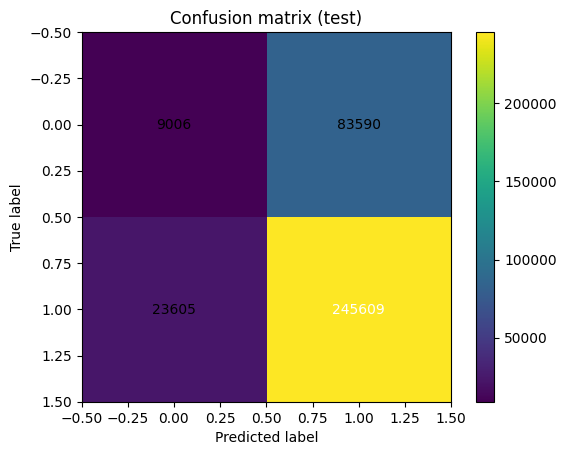

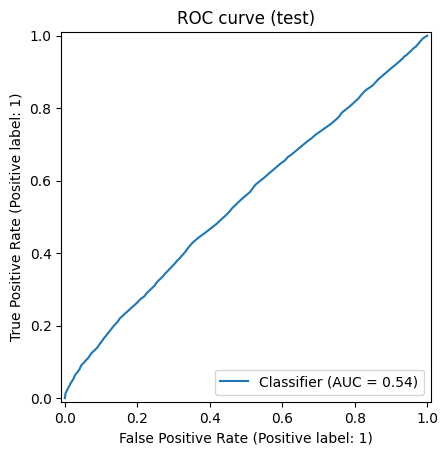

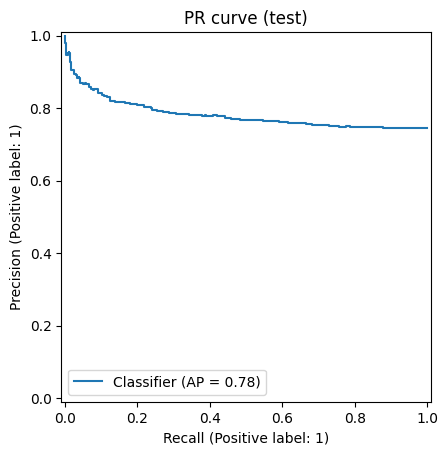

In [97]:
model, test_metrics, best_thr = train_lgbm_pipeline_cv(
    X_train=X_train.values,
    y_train=y_train.values,
    X_val=X_val.values,
    y_val=y_val.values,
    X_test=X_test.values,
    y_test=y_test.values,
    run_name="lgbm_cv_final_model",
    lgbm_params=lgbm_params_final,
    n_splits=5,
    seed=42
)

# 6. Modelado con Logistic Regression

## 6.1 Modelo sin optimización de hiperparámetros

In [79]:
mlflow.set_experiment("logisticregression")

<Experiment: artifact_location='mlflow-artifacts:/e0e291f27ebc46a9baa7eec35a967e21', creation_time=1768233124107, experiment_id='7', last_update_time=1768233124107, lifecycle_stage='active', name='logisticregression', tags={'mlflow.experimentKind': 'custom_model_development'}>

### MLlfow + CV

In [86]:
def train_logreg_pipeline_cv(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        run_name="logreg_baseline_cv",
        logreg_params=None,
        n_splits=5,
        seed=42
    ):

    figs_path = PathManager().get_abs_path_folder("figures")
    models_path = PathManager().get_abs_path_folder("models")
    if isinstance(models_path, list):
        models_path = [p for p in models_path if "spectralcrop" not in p][0]

    # =============================
    # Default params
    # =============================
    if logreg_params is None:
        logreg_params = {
            "penalty": "l2",
            "C": 1.0,
            "solver": "lbfgs",
            "max_iter": 1000,
            "class_weight": "balanced",
            "n_jobs": -1,
            "random_state": seed
        }

    # =============================
    # MLflow
    # =============================
    with mlflow.start_run(run_name=run_name):

        mlflow.log_params(logreg_params)
        mlflow.log_param("cv_folds", n_splits)
        mlflow.log_param("uses_pipeline_scaler", True)
        mlflow.log_param("model_type", "LogisticRegression")

        # =============================
        # 1️⃣ Cross-Validation (TRAIN)
        # =============================
        print("Ejecutando Cross-Validation (Logistic Regression)")

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )

        cv_scores = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):

            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]

            model_fold = Pipeline(steps=[
                ("scaler", RobustScaler()),
                ("logreg", LogisticRegression(**logreg_params))
            ])

            model_fold.fit(X_tr, y_tr)

            y_prob_va = model_fold.predict_proba(X_va)[:, 1]
            pr_auc = average_precision_score(y_va, y_prob_va)

            cv_scores.append(pr_auc)
            mlflow.log_metric(f"cv_fold_{fold}_pr_auc", pr_auc)

        mean_cv_pr = float(np.mean(cv_scores))
        std_cv_pr  = float(np.std(cv_scores))

        mlflow.log_metric("cv_mean_pr_auc", mean_cv_pr)
        mlflow.log_metric("cv_std_pr_auc", std_cv_pr)

        best_fold = int(np.argmax(cv_scores))
        mlflow.log_param("best_cv_fold", best_fold + 1)

        # =============================
        # 2️⃣ Final training (TRAIN)
        # =============================
        model = Pipeline(steps=[
            ("scaler", RobustScaler()),
            ("logreg", LogisticRegression(**logreg_params))
        ])

        model.fit(X_train, y_train)

        # =============================
        # 3️⃣ Threshold tuning (VAL)
        # =============================
        y_prob_val = model.predict_proba(X_val)[:, 1]

        thr_grid = np.linspace(0.10, 0.90, 161)
        best_thr, best_f1 = max(
            ((t, f1_score(y_val, (y_prob_val >= t).astype(int), average="macro"))
             for t in thr_grid),
            key=lambda x: x[1]
        )

        mlflow.log_metric("best_threshold", best_thr)
        mlflow.log_metric("val_best_f1_macro", best_f1)

        print(f"Umbral óptimo VAL: {best_thr:.3f} | F1_macro={best_f1:.3f}")

        # =============================
        # 4️⃣ TEST evaluation
        # =============================
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= best_thr).astype(int)

        test_metrics = {
            "test_pr_auc": average_precision_score(y_test, y_prob_test),
            "test_roc_auc": roc_auc_score(y_test, y_prob_test),
            "test_f1_macro": f1_score(y_test, y_pred_test, average="macro"),
            "test_precision": precision_score(y_test, y_pred_test),
            "test_recall": recall_score(y_test, y_pred_test),
            "test_accuracy": accuracy_score(y_test, y_pred_test),
        }

        mlflow.log_metrics(test_metrics)

        # =============================
        # Confusion matrix
        # =============================
        cm = confusion_matrix(y_test, y_pred_test)

        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion matrix (test)")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(
                    j, i, cm[i, j],
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black"
                )
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()

        artifact_path = figs_path + f"confusion_matrix_{run_name}.png"
        plt.savefig(artifact_path)
        mlflow.log_artifact(artifact_path)

        # =============================
        # ROC & PR curves
        # =============================
        RocCurveDisplay.from_predictions(y_test, y_prob_test)
        plt.title("ROC curve (test)")
        plt.savefig(figs_path + f"roc_curve_{run_name}.png")
        mlflow.log_artifact(figs_path + f"roc_curve_{run_name}.png")

        PrecisionRecallDisplay.from_predictions(y_test, y_prob_test)
        plt.title("PR curve (test)")
        plt.savefig(figs_path + f"pr_curve_{run_name}.png")
        mlflow.log_artifact(figs_path + f"pr_curve_{run_name}.png")

        # =============================
        # Save model
        # =============================
        joblib.dump(model, models_path + f"{run_name}.pkl")

        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            registered_model_name="bean_stress_classifier"
        )

    return model, test_metrics, best_thr


Ejecutando Cross-Validation (Logistic Regression)
Umbral óptimo VAL: 0.440 | F1_macro=0.542


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 11:10:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 30
Created version '30' of model 'bean_stress_classifier'.


🏃 View run logreg_baseline_cv at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/55653a8434554ca594d58c0d81eef77d
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7


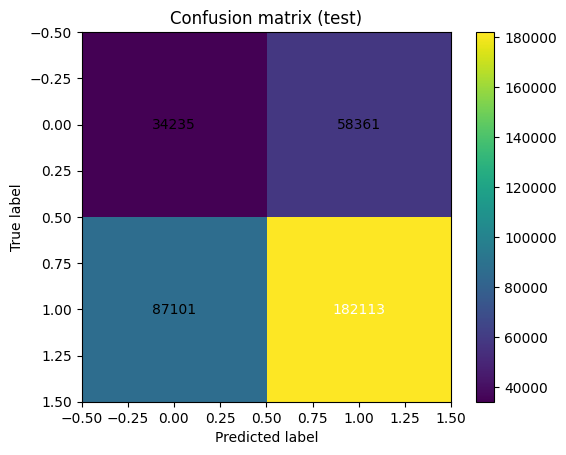

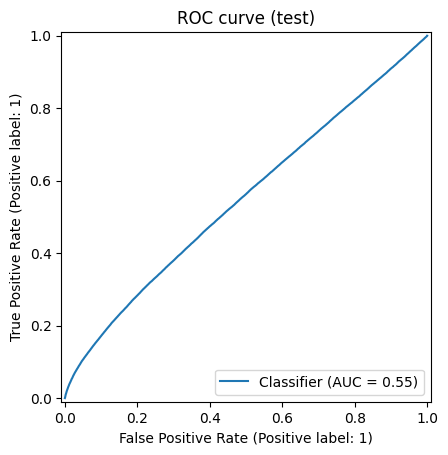

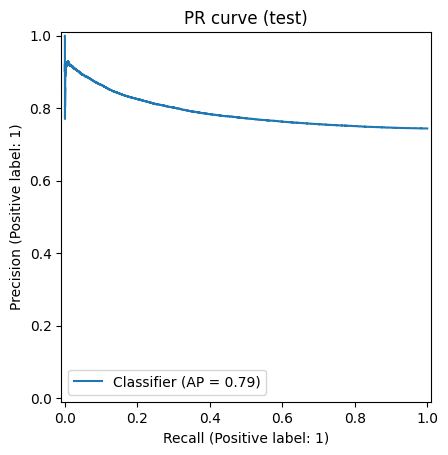

In [104]:
logreg_params = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 2000,
    "class_weight": "balanced",
    "n_jobs": -1,
    "random_state": 42
}

model, test_metrics, best_thr = train_logreg_pipeline_cv(
    X_train=X_train.values, y_train=y_train.values,
    X_val=X_val.values,     y_val=y_val.values,
    X_test=X_test.values,   y_test=y_test.values,
    run_name="logreg_baseline_cv",
    logreg_params=logreg_params,
    n_splits=5,
    seed=42
)

## 6.2 Optimización de hiperparámetros

### MLflow + optuna

In [80]:
def train_eval_trial_logreg(
    X_train, y_train,
    X_val,   y_val,
    logreg_params,
    trial=None,
    seed=42,
    verbose=False
):
    np.random.seed(seed)

    logreg_params = logreg_params.copy()
    logreg_params["random_state"] = seed

    # -----------------------------
    # Pipeline
    # -----------------------------
    model = Pipeline(steps=[
        ("scaler", RobustScaler()),
        ("logreg", LogisticRegression(**logreg_params))
    ])

    # -----------------------------
    # Fit
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # Validación
    # -----------------------------
    y_prob_val = model.predict_proba(X_val)[:, 1]

    pr_auc  = average_precision_score(y_val, y_prob_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)

    y_pred = (y_prob_val >= 0.5).astype(int)

    metrics = {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred),
    }

    # -----------------------------
    # Optuna prune (trial-level)
    # -----------------------------
    if trial is not None:
        trial.report(pr_auc, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

    if verbose:
        print(
            f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
            f"F1={metrics['f1_macro']:.4f}"
        )

    return metrics


In [81]:
def run_optuna_logreg(
    X_train, y_train,
    X_val,   y_val,
    n_trials=30,
    seed=42
):
    with mlflow.start_run(run_name="optuna_logistic_regression"):

        def objective(trial):

            # -------------------------
            # Hiperparámetros Optuna
            # -------------------------
            solver = trial.suggest_categorical(
                "solver", ["liblinear", "lbfgs"]
            )

            penalty = trial.suggest_categorical(
                "penalty", ["l1", "l2", "elasticnet"]
            )

            l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

            valid = (
                (solver == "liblinear" and penalty in ["l1", "l2"]) or
                (solver == "lbfgs"     and penalty in ["l2", "none"]) or
                (solver == "saga"      and penalty in ["l1", "l2", "elasticnet"])
            )

            if not valid:
                raise optuna.TrialPruned()

            logreg_params = {
                "solver": solver,
                "penalty": penalty,
                "C": trial.suggest_float("C", 1e-3, 1.0, log=True),
                "class_weight": "balanced",
                "max_iter": trial.suggest_int("max_iter", 500, 1500),
                "n_jobs": -1,
            }

            if penalty == "elasticnet":
                logreg_params["l1_ratio"] = l1_ratio

            try:
                with mlflow.start_run(
                    run_name=f"logreg_trial_{trial.number}",
                    nested=True
                ):
                    # -------------------------
                    # Log params
                    # -------------------------
                    mlflow.log_params(logreg_params)

                    # -------------------------
                    # Train + VAL
                    # -------------------------
                    metrics = train_eval_trial_logreg(
                        X_train=X_train, y_train=y_train,
                        X_val=X_val,     y_val=y_val,
                        logreg_params=logreg_params,
                        trial=trial,
                        verbose=True
                    )

                    # -------------------------
                    # Log metrics
                    # -------------------------
                    mlflow.log_metrics(metrics)
                    mlflow.log_param("trial_status", "completed")

                    return metrics["pr_auc"]

            except optuna.TrialPruned:
                mlflow.log_param("trial_status", "pruned")
                raise

            except Exception as e:
                mlflow.log_param("trial_status", "failed_exception")
                print(f"❌ Trial {trial.number} failed: {e}")
                return None

        # -------------------------
        # Optuna study
        # -------------------------
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
            pruner=optuna.pruners.MedianPruner(
                n_startup_trials=5
            )
        )

        study.optimize(objective, n_trials=n_trials)

        # -------------------------
        # Log best
        # -------------------------
        mlflow.log_metric("best_val_pr_auc", study.best_value)
        mlflow.log_params(
            {f"best_{k}": v for k, v in study.best_params.items()}
        )

        print("Best PR-AUC:", study.best_value)
        print("Best params:", study.best_params)

        return study


In [82]:
study_logreg = run_optuna_logreg(
    X_train=X_train.values, y_train=y_train.values,
    X_val=X_val.values,     y_val=y_val.values,
    n_trials=20,
    seed=42
)

best_params_logreg = study_logreg.best_params
print(best_params_logreg)


[I 2026-01-12 15:22:05,201] A new study created in memory with name: no-name-7129d127-dc5b-4ac3-8286-f9c6d9299f4b
[I 2026-01-12 15:22:05,213] Trial 0 pruned. 


PR-AUC=0.7930 | ROC-AUC=0.5832 | F1=0.5257
🏃 View run logreg_trial_1 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/a40fbf369a3a43778871fa681cf8e23d
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7


[I 2026-01-12 15:22:48,330] Trial 1 finished with value: 0.7929830840123202 and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'l1_ratio': 0.9699098521619943, 'C': 0.31428808908401085, 'max_iter': 712}. Best is trial 1 with value: 0.7929830840123202.


PR-AUC=0.7931 | ROC-AUC=0.5832 | F1=0.5257


[I 2026-01-12 15:23:21,410] Trial 2 finished with value: 0.7930654492448662 and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'l1_ratio': 0.2912291401980419, 'C': 0.06847920095574778, 'max_iter': 639}. Best is trial 2 with value: 0.7930654492448662.


...

🏃 View run logreg_trial_17 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/fa470bc02c0241beb006da03053e0860
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7


[I 2026-01-12 15:54:06,385] Trial 17 pruned. 


🏃 View run logreg_trial_18 at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/44e9fc5cb0bf4f128110518b739fefeb
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7


[I 2026-01-12 16:48:43,825] Trial 18 pruned. 
[I 2026-01-12 16:48:43,832] Trial 19 pruned. 


Best PR-AUC: 0.7931600110704193
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'l1_ratio': 0.4418646837803779, 'C': 0.04044574059404954, 'max_iter': 518}
🏃 View run optuna_logistic_regression at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/525e6a6d493c424cbe8d725401e7190c
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7
{'solver': 'lbfgs', 'penalty': 'l2', 'l1_ratio': 0.4418646837803779, 'C': 0.04044574059404954, 'max_iter': 518}


### Entrenamiento modelo final

In [89]:
logreg_params_final = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 2000,
    "class_weight": "balanced",
    "n_jobs": -1,
    "random_state": 42
}

logreg_params_final.update(best_params_logreg)

logreg_params_final



{'penalty': 'l2',
 'C': 0.04044574059404954,
 'solver': 'lbfgs',
 'max_iter': 518,
 'class_weight': 'balanced',
 'n_jobs': -1,
 'random_state': 42,
 'l1_ratio': 0.4418646837803779}

Ejecutando Cross-Validation (Logistic Regression)
Umbral óptimo VAL: 0.445 | F1_macro=0.542


Registered model 'bean_stress_classifier' already exists. Creating a new version of this model...
2026/01/12 17:05:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: bean_stress_classifier, version 32
Created version '32' of model 'bean_stress_classifier'.


🏃 View run logreg_cv_final_model at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7/runs/5c2825036d484209806ea2de724f0d79
🧪 View experiment at: https://dagshub.com/johnma96/thesis.mlflow/#/experiments/7


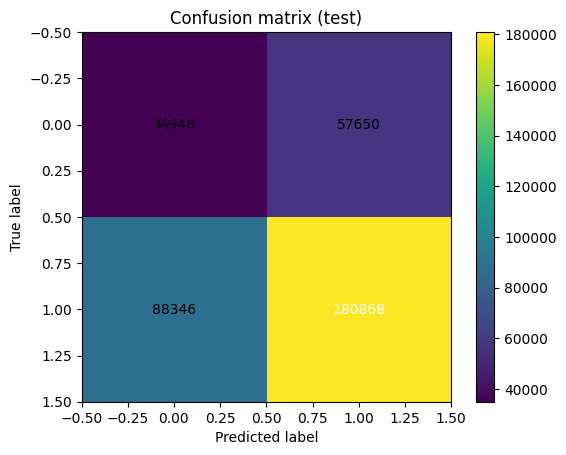

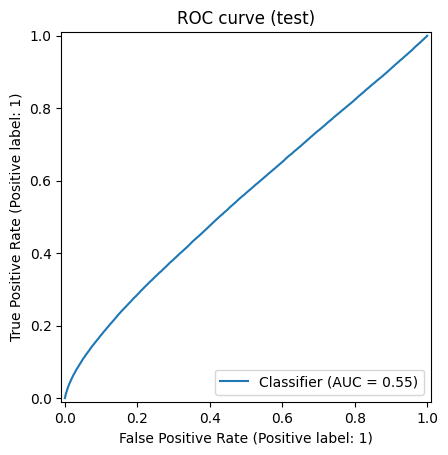

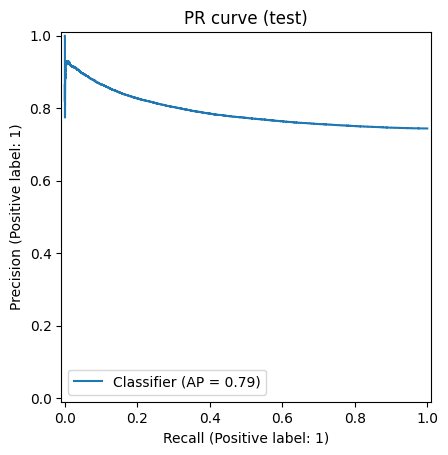

In [90]:
model, test_metrics, best_thr = train_logreg_pipeline_cv(
    X_train=X_train.values, y_train=y_train.values,
    X_val=X_val.values,     y_val=y_val.values,
    X_test=X_test.values,   y_test=y_test.values,
    run_name="logreg_cv_final_model",
    logreg_params=logreg_params_final,
    n_splits=5,
    seed=42
)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Métricas seleccionadas (puedes ajustar)
metrics = [
    "test_pr_auc",
    "test_roc_auc",
    "test_f1_macro",
    "test_precision",
    "test_recall",
    "test_accuracy"
]

# Resultados
data = {
    "logreg_baseline":        [0.789, 0.551, 0.517, 0.757, 0.676, 0.598],
    "logreg_final":           [0.790, 0.553, 0.518, 0.758, 0.672, 0.596],
    "sgd_baseline":           [0.785, 0.549, 0.520, 0.757, 0.703, 0.611],
    "sgd_final":              [0.789, 0.551, 0.518, 0.756, 0.691, 0.604],
    "lgbm_baseline":          [0.778, 0.536, 0.433, 0.778, 0.337, 0.435],
    "lgbm_final":             [0.782, 0.545, 0.482, 0.746, 0.912, 0.704],
    "xgboost_baseline":       [0.822, 0.612, 0.559, 0.779, 0.729, 0.644],
    "xgboost_final":          [0.824, 0.615, 0.561, 0.782, 0.720, 0.642],
}

df = pd.DataFrame(data, index=metrics)


<Figure size 1400x600 with 0 Axes>

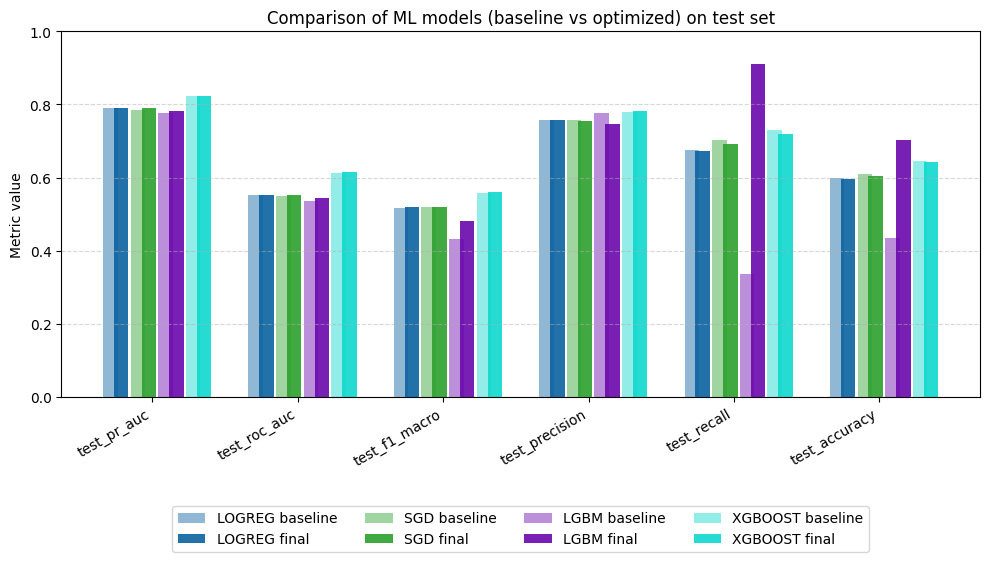

In [22]:
# Parámetros del gráfico
n_metrics = len(metrics)
n_models = df.shape[1]

x = np.arange(n_metrics)
bar_width = 0.10

plt.figure(figsize=(14, 6))

# Colores por algoritmo
algo_colors = {
    "logreg":  "#0a62a0",  # azul
    "sgd":     "#2ca02c",  # verde
    "lgbm":    "#6a07ac",  # naranja
    "xgboost": "#0dd8ce",  # rojo
}

alpha_baseline = 0.45
alpha_final = 0.9


import numpy as np
import matplotlib.pyplot as plt

# DataFrame df ya creado previamente
# df.index = metrics
# df.columns = modelos

x = np.arange(len(metrics))
bar_width = 0.1

plt.figure(figsize=(10, 6))

offsets = {
    "logreg": -2.9 * bar_width,
    "sgd":    -1 * bar_width,
    "lgbm":    0.9 * bar_width,
    "xgboost": 2.8 * bar_width,
}

for algo in ["logreg", "sgd", "lgbm", "xgboost"]:
    # baseline
    plt.bar(
        x + offsets[algo],
        df[f"{algo}_baseline"].values,
        width=bar_width,
        color=algo_colors[algo],
        alpha=alpha_baseline,
        label=f"{algo.upper()} baseline"
    )

    # final
    plt.bar(
        x + offsets[algo] + bar_width*0.75,
        df[f"{algo}_final"].values,
        width=bar_width,
        color=algo_colors[algo],
        alpha=alpha_final,
        label=f"{algo.upper()} final"
    )

# Ejes y formato
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Metric value")
plt.title("Comparison of ML models (baseline vs optimized) on test set")

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Leyenda compacta
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # eliminar duplicados
plt.legend(
    by_label.values(),
    by_label.keys(),
    ncol=4,
    bbox_to_anchor=(0.5, -0.28),
    loc="upper center"
)

plt.tight_layout()
plt.show()
